## Cell 0 — Base Pipeline Rebuild

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH   = "/content/drive/MyDrive/Colab Notebooks/SDG6-7/files/"
RESULT_PATH = "/content/drive/MyDrive/Colab Notebooks/SDG6-7/outputs/"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# CELL DIAG — Locate the PDFs
# ============================================================
import os

CANDIDATE_PATHS = [
    "/content/drive/MyDrive/Colab Notebooks/SDG6-7/files/",
    "/content/drive/MyDrive/Colab Notebooks/SDG6-7/",
    "/content/drive/MyDrive/Colab Notebooks/SDG6-7/PDFs/",
    "/content/drive/MyDrive/Colab Notebooks/SDG6-7/pdf/",
    "/content/drive/MyDrive/Colab Notebooks/SDG6-7/papers/",
    "/content/drive/MyDrive/SDG6-7/",
    "/content/drive/MyDrive/SDG6-7/files/",
]

print("=" * 70)
print("CHECKING CANDIDATE PATHS")
print("=" * 70)
for p in CANDIDATE_PATHS:
    if os.path.isdir(p):
        # Count PDFs at this level + recursively
        flat_pdfs = [f for f in os.listdir(p) if f.lower().endswith(".pdf")]
        rec_pdfs  = []
        for root, _, files in os.walk(p):
            for f in files:
                if f.lower().endswith(".pdf"):
                    rec_pdfs.append(os.path.join(root, f))
        print(f"EXISTS:    {p}")
        print(f"  flat PDFs at top level:  {len(flat_pdfs)}")
        print(f"  recursive PDFs (subdirs): {len(rec_pdfs)}")
        if rec_pdfs[:3]:
            print(f"  sample: {[os.path.basename(x) for x in rec_pdfs[:3]]}")
        print()
    else:
        print(f"NOT FOUND: {p}")

print()
print("=" * 70)
print("WHAT IS IN /content/drive/MyDrive/Colab Notebooks/")
print("=" * 70)
parent = "/content/drive/MyDrive/Colab Notebooks/"
if os.path.isdir(parent):
    for item in sorted(os.listdir(parent)):
        full = os.path.join(parent, item)
        kind = "DIR" if os.path.isdir(full) else "FILE"
        print(f"  [{kind}] {item}")
else:
    print(f"NOT FOUND: {parent}")

print()
print("=" * 70)
print("FULL TREE OF SDG6-7 FOLDER (if it exists)")
print("=" * 70)
sdg_root = "/content/drive/MyDrive/Colab Notebooks/SDG6-7"
if os.path.isdir(sdg_root):
    for root, dirs, files in os.walk(sdg_root):
        depth = root.replace(sdg_root, "").count(os.sep)
        indent = "  " * depth
        print(f"{indent}{os.path.basename(root) or sdg_root}/")
        sub_indent = "  " * (depth + 1)
        # Show file count + sample
        if files:
            pdf_count = sum(1 for f in files if f.lower().endswith(".pdf"))
            other     = len(files) - pdf_count
            print(f"{sub_indent}({pdf_count} PDFs, {other} other files)")
            for f in files[:5]:
                print(f"{sub_indent}  {f}")
            if len(files) > 5:
                print(f"{sub_indent}  ... and {len(files)-5} more")
else:
    print(f"NOT FOUND: {sdg_root}")


CHECKING CANDIDATE PATHS
NOT FOUND: /content/drive/MyDrive/Colab Notebooks/SDG6-7/files/
EXISTS:    /content/drive/MyDrive/Colab Notebooks/SDG6-7/
  flat PDFs at top level:  0
  recursive PDFs (subdirs): 460
  sample: ['SDG6-65.pdf', 'SDG6-175.pdf', 'SDG6-91.pdf']

NOT FOUND: /content/drive/MyDrive/Colab Notebooks/SDG6-7/PDFs/
NOT FOUND: /content/drive/MyDrive/Colab Notebooks/SDG6-7/pdf/
NOT FOUND: /content/drive/MyDrive/Colab Notebooks/SDG6-7/papers/
NOT FOUND: /content/drive/MyDrive/SDG6-7/
NOT FOUND: /content/drive/MyDrive/SDG6-7/files/

WHAT IS IN /content/drive/MyDrive/Colab Notebooks/
  [DIR] 3-16
  [DIR] AILit
  [DIR] Academic Gen AI MBAR Iliana
  [DIR] Ai-ethics
  [FILE] Copy of DTSDG14-15.ipynb
  [DIR] DTO4-10
  [DIR] DTSDG1-2
  [DIR] DTSDG12-13
  [DIR] DTSDG14-15
  [DIR] DTSDG5-8
  [DIR] DTSDG58
  [DIR] DTSDG6-7
  [DIR] DTSDG9-11
  [DIR] Episodes
  [DIR] Ethics
  [DIR] Evaluation
  [DIR] IFResearch
  [DIR] ISLCNC-TAM
  [DIR] Learning
  [DIR] Methodology
  [DIR] Motherhood
  [

In [15]:
# ============================================================
# CELL 0 — BASE PIPELINE REBUILD (V7 PATCHED)
# ============================================================
# V7 changes from V6:
#   - Patterns now match three termination forms:
#       (1) "Heading\n" (block form)
#       (2) "Heading: text..." (inline with colon)
#       (3) "Heading. text..." (inline with period)
#   - Roman numeral section numbering supported (I., II., III., IV., etc.)
#   - "RESEARCH METHODOLOGY" compound heading caught
#   - "Conclusion and recommendations/implications/suggestions" caught
#
# V6 boundary-filtering logic retained:
#   - Section boundaries appearing BEFORE the introduction are dropped
#     (they are structured-abstract sub-labels like Findings:, Conclusion:,
#     Discussion: inside the abstract block).
#
# Handles documented PDF parsing failure modes:
#   1. Decimal section numbering (1.0 Introduction, 3.1. Methodology)
#   2. Subsection numbering with no space (1.1.Introduction)
#   3. Inline colon-style headings (Methodology: This study...)
#   4. Inline abstract (Abstract: Despite water scarcity...)
#   5. Roman numeral numbering (I. INTRODUCTION, IV. RESULTS)
#   6. All-caps headings (METHODOLOGY, MATERIALS AND METHODS)
#   7. Compound headings (Findings And Discussion, RESEARCH METHODOLOGY)
#   8. Structured abstracts with sub-labels (Findings:/Conclusion:)
#
# Image-only PDFs (no text layer) cannot be recovered without OCR
# and are correctly identified as skipped_short.
# ============================================================

!pip -q install pypdf pdfplumber sentence-transformers scikit-learn networkx

import os, re, random, warnings
import numpy as np
import pandas as pd
import pdfplumber

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# -----------------------------
# MOUNT DRIVE + PATHS
# -----------------------------
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH   = "/content/drive/MyDrive/Colab Notebooks/SDG6-7/filesp/"
RESULT_PATH = "/content/drive/MyDrive/Colab Notebooks/SDG6-7/outputs/"
os.makedirs(RESULT_PATH, exist_ok=True)

# -----------------------------
# CLEAN PRIOR OUTPUTS
# -----------------------------
for f in ["df_documents_full.csv", "df_metadata.csv", "df_corpus_index.csv",
          "df_theory_similarity.csv", "df_sdg_similarity.csv", "df_master.csv",
          "doc_embeddings.npy"]:
    p = os.path.join(RESULT_PATH, f)
    if os.path.exists(p):
        os.remove(p)
        print(f"Removed prior output: {f}")

# -----------------------------
# PRE-FLIGHT
# -----------------------------
if not os.path.isdir(BASE_PATH):
    raise FileNotFoundError(f"BASE_PATH does not exist: {BASE_PATH}")

all_pdf_paths = []
for root, _, files in os.walk(BASE_PATH):
    for f in files:
        if f.lower().endswith(".pdf"):
            all_pdf_paths.append(os.path.join(root, f))

print(f"\nBASE_PATH:        {BASE_PATH}")
print(f"PDFs found:       {len(all_pdf_paths)}")
if len(all_pdf_paths) == 0:
    raise FileNotFoundError(f"No PDFs found under {BASE_PATH}")

# -----------------------------
# V7 SECTION PATTERNS
# -----------------------------
# Termination form: either ":" + space (inline), "." + space (inline), or \n (block)
SECTION_PATTERNS = {
    "abstract":     re.compile(r"(?:^|\n)\s*abstract(?:\s*[:\.]\s|\s*\n)", re.IGNORECASE),
    "introduction": re.compile(r"(?:^|\n)\s*(?:(?:\d+(?:\.\d+)*\.?|[IVX]+\.)\s*)?(?:introduction(?:\s+and\s+literature\s+review)?|background)(?:\s*[:\.]\s|\s*\n)", re.IGNORECASE),
    "methodology":  re.compile(r"(?:^|\n)\s*(?:(?:\d+(?:\.\d+)*\.?|[IVX]+\.)\s*)?(?:research\s+)?(?:method(?:s|ology)?|materials?\s+and\s+methods?|research\s+design|research\s+methods?|methodological\s+approach)(?:\s*[:\.]\s|\s*\n)", re.IGNORECASE),
    "results":      re.compile(r"(?:^|\n)\s*(?:(?:\d+(?:\.\d+)*\.?|[IVX]+\.)\s*)?(?:results?(?:\s+and\s+discussion)?|findings?(?:\s+and\s+discussion)?|empirical\s+results?|research\s+findings?)(?:\s*[:\.]\s|\s*\n)", re.IGNORECASE),
    "discussion":   re.compile(r"(?:^|\n)\s*(?:(?:\d+(?:\.\d+)*\.?|[IVX]+\.)\s*)?(?:discussions?(?:\s+and\s+implications?)?|analysis|interpretation)(?:\s*[:\.]\s|\s*\n)", re.IGNORECASE),
    "conclusion":   re.compile(r"(?:^|\n)\s*(?:(?:\d+(?:\.\d+)*\.?|[IVX]+\.)\s*)?(?:conclusions?(?:\s+and\s+(?:recommendations?|implications?|suggestions?))?|concluding\s+remarks)(?:\s*[:\.]\s|\s*\n)", re.IGNORECASE),
    "references":   re.compile(r"(?:^|\n)\s*(?:references|bibliography|works\s+cited)\s*\n", re.IGNORECASE),
}
SECTION_KEYS = ["abstract","introduction","methodology","results","discussion","conclusion"]

def extract_pdf_text(path):
    text = ""
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            t = page.extract_text() or ""
            text += t + "\n"
    return text

def extract_sections_positional(text):
    """V6 boundary logic + V7 patterns.

    Boundaries appearing before the introduction are NOT treated as
    section breaks. This protects the abstract from being fragmented
    by structured-abstract sub-labels (Findings:, Conclusion:, etc.)
    inside the abstract block.

    Last-write-wins still applies for duplicate section names appearing
    after the introduction (real headings overwrite spurious ones)."""

    # Find all boundaries
    boundaries = []
    for name, pat in SECTION_PATTERNS.items():
        for m in pat.finditer(text):
            boundaries.append((m.start(), m.end(), name))
    boundaries.sort()

    # Find the position of the FIRST introduction boundary (if any)
    intro_pos = None
    for start, end, name in boundaries:
        if name == "introduction":
            intro_pos = start
            break

    # Filter out structured-abstract sub-labels:
    # Always keep abstract; drop other boundaries that appear before the
    # introduction once abstract has been seen (they are sub-labels).
    if intro_pos is not None:
        filtered = []
        seen_abstract = False
        for start, end, name in boundaries:
            if name == "abstract":
                filtered.append((start, end, name))
                seen_abstract = True
            elif start < intro_pos and seen_abstract:
                continue
            else:
                filtered.append((start, end, name))
        boundaries = filtered

    # Slice text between consecutive boundaries
    sections = {k: "" for k in SECTION_KEYS}
    for i, (start, end, name) in enumerate(boundaries):
        if name == "references":
            continue
        next_start = boundaries[i+1][0] if i+1 < len(boundaries) else len(text)
        sections[name] = text[end:next_start].strip()

    return sections

# -----------------------------
# WALK + EXTRACT
# -----------------------------
records, metadata, index = [], [], []
n_total = len(all_pdf_paths)

for i, path in enumerate(all_pdf_paths, 1):
    f = os.path.basename(path)
    if i % 25 == 0 or i == n_total:
        print(f"  Processing {i}/{n_total}: {f[:60]}")
    try:
        full_text = extract_pdf_text(path)
        if not full_text or len(full_text.strip()) < 100:
            index.append({"filename": f, "path": path, "status": "skipped_no_text"})
            continue

        sections = extract_sections_positional(full_text)
        joined   = " ".join(sections.values()).strip()

        if len(joined) < 300:
            sections = {k: "" for k in SECTION_KEYS}
            sections["abstract"] = full_text.strip()[:5000]
            joined = sections["abstract"]
            status = "fallback_no_sections_detected"
        else:
            status = "ok"

        if len(joined) < 300:
            index.append({"filename": f, "path": path, "status": "skipped_short"})
            continue

        paper_id = re.sub(r"\.pdf$", "", f, flags=re.IGNORECASE)
        records.append({
            "paper_id":     paper_id,
            "text":         joined,
            "abstract":     sections["abstract"],
            "introduction": sections["introduction"],
            "methodology":  sections["methodology"],
            "results":      sections["results"],
            "discussion":   sections["discussion"],
            "conclusion":   sections["conclusion"],
        })
        metadata.append({
            "paper_id": paper_id,
            "title":    full_text.split("\n",1)[0][:300],
            "filename": f,
        })
        index.append({"filename": f, "path": path, "status": status})
    except Exception as e:
        index.append({"filename": f, "path": path, "status": f"error: {str(e)[:80]}"})

# -----------------------------
# SAVE
# -----------------------------
df_documents = pd.DataFrame(records, columns=["paper_id","text","abstract","introduction",
                                              "methodology","results","discussion","conclusion"])
df_metadata  = pd.DataFrame(metadata, columns=["paper_id","title","filename"])
df_index     = pd.DataFrame(index,    columns=["filename","path","status"])

df_documents.to_csv(os.path.join(RESULT_PATH, "df_documents_full.csv"), index=False)
df_metadata.to_csv(os.path.join(RESULT_PATH,  "df_metadata.csv"),       index=False)
df_index.to_csv(os.path.join(RESULT_PATH,     "df_corpus_index.csv"),   index=False)

# -----------------------------
# REPORT
# -----------------------------
print()
print("=" * 60)
print(f"Corpus extracted: {df_documents.shape[0]} papers")
if len(df_index) > 0:
    print()
    print("Status breakdown:")
    print(df_index["status"].value_counts())

if len(df_documents) > 0:
    print()
    print("Section coverage (% papers with content > 50 chars):")
    for col in SECTION_KEYS:
        pct = 100 * (df_documents[col].str.len() > 50).mean()
        bar = "#" * int(pct/2)
        print(f"  {col:14s} {pct:5.1f}%  {bar}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

BASE_PATH:        /content/drive/MyDrive/Colab Notebooks/SDG6-7/filesp/
PDFs found:       459
  Processing 25/459: SDG6-41.pdf
  Processing 50/459: SDG6-42.pdf
  Processing 75/459: SDG6-116.pdf
  Processing 100/459: SDG6-200.pdf
  Processing 125/459: SDG6-09.pdf
  Processing 150/459: SDG6-23.pdf
  Processing 175/459: SDG6-162.pdf
  Processing 200/459: SDG6-79.pdf
  Processing 225/459: SDG7-113.pdf
  Processing 250/459: SDG7-107.pdf
  Processing 275/459: SDG7-198.pdf
  Processing 300/459: SDG7-205.pdf
  Processing 325/459: SDG7-126.pdf
  Processing 350/459: SDG7-148.pdf
  Processing 375/459: SDG7-100.pdf
  Processing 400/459: SDG7-157.pdf


  Processing 425/459: SDG7-174.pdf
  Processing 450/459: IoT-07-00005.pdf
  Processing 459/459: sustainability-18-03178.pdf

Corpus extracted: 457 papers

Status breakdown:
status
ok                                                 397
fallback_no_sections_detected                       60
skipped_no_text                                      1
error: No /Root object! - Is this really a PDF?      1
Name: count, dtype: int64

Section coverage (% papers with content > 50 chars):
  abstract        63.9%  ###############################
  introduction    54.9%  ###########################
  methodology     43.1%  #####################
  results         40.5%  ####################
  discussion      40.7%  ####################
  conclusion      53.6%  ##########################


In [17]:
df = pd.read_csv(os.path.join(RESULT_PATH, "df_documents_full.csv"))

test_papers = ["SDG6-65", "SDG6-56", "SDG6-111", "SDG6-168", "SDG6-133",
               "SDG6-12", "SDG6-41", "SDG6-83", "SDG6-91", "SDG6-110", "SDG6-175"]

print("Verification of previously-broken papers:")
for pid in test_papers:
    row = df[df["paper_id"] == pid]
    if len(row) == 0:
        print(f"  {pid}: NOT FOUND")
        continue
    abs_len  = len(str(row["abstract"].iloc[0] or ""))
    intro_len = len(str(row["introduction"].iloc[0] or ""))
    disc_len = len(str(row["discussion"].iloc[0] or ""))
    status = "OK" if abs_len > 50 else "STILL BROKEN"
    print(f"  {pid}: abs={abs_len:5d}  intro={intro_len:5d}  disc={disc_len:5d}  {status}")

Verification of previously-broken papers:
  SDG6-65: abs=    3  intro=15888  disc= 1080  STILL BROKEN
  SDG6-56: abs=    3  intro=49174  disc=    3  STILL BROKEN
  SDG6-111: abs=    3  intro=10847  disc= 7009  STILL BROKEN
  SDG6-168: abs=    3  intro=    3  disc= 1634  STILL BROKEN
  SDG6-133: abs=    3  intro=12656  disc= 4927  STILL BROKEN
  SDG6-12: abs=    3  intro=19517  disc= 9571  STILL BROKEN
  SDG6-41: abs= 2112  intro=29723  disc=11840  OK
  SDG6-83: abs= 1913  intro=23319  disc=    3  OK
  SDG6-91: abs= 4208  intro=61458  disc=    3  OK
  SDG6-110: abs=    3  intro= 2183  disc= 2232  STILL BROKEN
  SDG6-175: abs= 2481  intro=16377  disc=    3  OK


In [18]:
# ============================================================
# DIAGNOSTIC — Where is the discussion content?
# ============================================================
import os, pandas as pd

df = pd.read_csv(os.path.join(RESULT_PATH, "df_documents_full.csv"))

# Strip + length per section
for col in ["abstract", "introduction", "results", "discussion", "conclusion"]:
    df[f"{col}_len"] = df[col].fillna("").str.len()

# Three groups of papers by where discussion content sits
has_disc        = df["discussion_len"] > 50
disc_in_results = (df["discussion_len"] < 50) & (df["results_len"] > 1000)
disc_in_concl   = (df["discussion_len"] < 50) & (df["conclusion_len"] > 1000)
truly_missing   = (df["discussion_len"] < 50) & (df["results_len"] < 500) & (df["conclusion_len"] < 500)

print(f"Total papers: {len(df)}")
print(f"  Has labeled discussion section:           {has_disc.sum():3d}  ({100*has_disc.mean():.1f}%)")
print(f"  Discussion likely merged into results:    {disc_in_results.sum():3d}  ({100*disc_in_results.mean():.1f}%)")
print(f"  Discussion likely merged into conclusion: {disc_in_concl.sum():3d}  ({100*disc_in_concl.mean():.1f}%)")
print(f"  Discussion content genuinely absent:      {truly_missing.sum():3d}  ({100*truly_missing.mean():.1f}%)")
print()

# Effective discussion-content coverage
effective = has_disc | disc_in_results | disc_in_concl
print(f"Papers with discussion content somewhere:   {effective.sum():3d}  ({100*effective.mean():.1f}%)")
print()
print("If 'effective coverage' is >80%, discussion content is recoverable")
print("via the text or results/conclusion fields. No re-extraction needed.")

Total papers: 457
  Has labeled discussion section:           186  (40.7%)
  Discussion likely merged into results:     71  (15.5%)
  Discussion likely merged into conclusion: 105  (23.0%)
  Discussion content genuinely absent:      125  (27.4%)

Papers with discussion content somewhere:   328  (71.8%)

If 'effective coverage' is >80%, discussion content is recoverable
via the text or results/conclusion fields. No re-extraction needed.


In [13]:
# ============================================================
# COMPARE: heading detection vs. content extraction
# ============================================================
import os, pandas as pd

df = pd.read_csv(os.path.join(RESULT_PATH, "df_documents_full.csv"))

# For each section, count three states:
#   - Has heading detected (would be "YES" in diagnostic)
#   - Has content > 50 chars (actually usable downstream)
#   - Has heading but no content (extraction failure)
# We can only check the "has content" part from the dataframe.
# Send the diagnostic terminal output and we cross-tabulate.

print(f"Total papers in df_documents_full: {len(df)}")
print()
print("Content extraction (>50 chars) by section:")
for col in ["abstract","introduction","methodology","results","discussion","conclusion"]:
    has_content = (df[col].fillna("").str.len() > 50).sum()
    pct = 100 * has_content / len(df)
    print(f"  {col:14s}  {has_content:3d}/{len(df)} = {pct:.1f}%")

print()
print("Sample papers with empty abstract field (first 20):")
empty_abs = df[df["abstract"].fillna("").str.len() < 50]["paper_id"].tolist()[:20]
for p in empty_abs:
    print(f"  {p}")

print()
print("Sample papers with empty discussion field (first 20):")
empty_disc = df[df["discussion"].fillna("").str.len() < 50]["paper_id"].tolist()[:20]
for p in empty_disc:
    print(f"  {p}")

Total papers in df_documents_full: 457

Content extraction (>50 chars) by section:
  abstract        254/457 = 55.6%
  introduction    247/457 = 54.0%
  methodology     164/457 = 35.9%
  results         160/457 = 35.0%
  discussion      150/457 = 32.8%
  conclusion      239/457 = 52.3%

Sample papers with empty abstract field (first 20):
  SDG6-65
  SDG6-77
  SDG6-07
  SDG6-06
  SDG6-56
  SDG6-111
  SDG6-168
  SDG6-202
  SDG6-110
  SDG6-83
  SDG6-133
  SDG6-12
  SDG6-01
  SDG6-41
  SDG6-82
  SDG6-146
  SDG6-130
  SDG6-92
  SDG6-121
  SDG6-183

Sample papers with empty discussion field (first 20):
  SDG6-175
  SDG6-91
  SDG6-77
  SDG6-36
  SDG6-199
  SDG6-07
  SDG6-06
  SDG6-56
  SDG6-202
  SDG6-83
  SDG6-50
  SDG6-01
  SDG6-129
  SDG6-55
  SDG6-82
  SDG6-130
  SDG6-92
  SDG6-121
  SDG6-102
  SDG6-183


In [19]:
# ============================================================
# CELL 0b — THEORY + SDG SIMILARITY + MASTER TABLE
# ============================================================

DT_THEORY_TEXTS = {
    "TAM":                  "technology acceptance usefulness ease of use perceived usefulness perceived ease",
    "UTAUT":                "performance expectancy effort expectancy social influence facilitating conditions",
    "STS":                  "socio technical systems human technology interaction joint optimization",
    "TOE":                  "technology organization environment framework adoption context",
    "RBV":                  "resource based view capabilities competitive advantage firm resources",
    "Dynamic_Capabilities": "sensing seizing transforming dynamic capabilities reconfiguration",
    "IDT":                  "innovation diffusion adoption rogers relative advantage compatibility",
    "Stakeholder_Theory":   "stakeholder governance multi stakeholder accountability legitimacy",
    "Just_Digital":         "digital justice inclusion equity fairness procedural distributive",
}

SDG_TEXTS = {
    "SDG6_Water": (
        "water sanitation clean water wastewater water quality water security "
        "drinking water access hygiene water infrastructure water governance "
        "water management water distribution water supply wastewater treatment "
        "sewerage water systems hydrology water scarcity water stress "
        "water resource management integrated water management irrigation "
        "water pollution contamination water reuse desalination water utilities "
        "smart water digital water water monitoring water IoT "
        "water data analytics sensor networks water systems resilience "
        "public water services sanitation services hygiene access inequality water"
    ),
    "SDG7_Energy": (
        "energy renewable energy clean energy electricity power systems energy access "
        "energy infrastructure energy systems energy transition sustainable energy "
        "energy efficiency energy consumption energy production electricity access "
        "energy policy energy governance smart grid digital energy energy IoT "
        "energy analytics demand response load management grid optimization "
        "distributed energy microgrid solar energy wind energy hydropower "
        "energy storage battery systems decarbonization energy markets "
        "energy resilience energy systems integration energy sustainability "
        "cyber physical energy systems digital twin energy systems"
    ),
}

model = SentenceTransformer("all-MiniLM-L6-v2")

doc_emb     = model.encode(df_documents["text"].tolist(),         normalize_embeddings=True)
theory_emb  = model.encode(list(DT_THEORY_TEXTS.values()),        normalize_embeddings=True)
sdg_emb     = model.encode(list(SDG_TEXTS.values()),              normalize_embeddings=True)

# -----------------------------
# THEORY SIMILARITY
# -----------------------------
theory_labels = list(DT_THEORY_TEXTS.keys())
sim_theory = cosine_similarity(doc_emb, theory_emb)

df_theory = pd.DataFrame(sim_theory, columns=theory_labels)
df_theory.insert(0, "paper_id", df_documents["paper_id"].values)
df_theory["dominant_dt_theory"] = df_theory[theory_labels].idxmax(axis=1)
df_theory.to_csv(os.path.join(RESULT_PATH, "df_theory_similarity.csv"), index=False)

# -----------------------------
# SDG SIMILARITY
# -----------------------------
sdg_labels = list(SDG_TEXTS.keys())
sim_sdg = cosine_similarity(doc_emb, sdg_emb)

df_sdg = pd.DataFrame(sim_sdg, columns=sdg_labels)
df_sdg.insert(0, "paper_id", df_documents["paper_id"].values)
df_sdg["dominant_sdg"] = df_sdg[sdg_labels].idxmax(axis=1)
df_sdg["sdg_margin"]   = df_sdg["SDG6_Water"] - df_sdg["SDG7_Energy"]
df_sdg.to_csv(os.path.join(RESULT_PATH, "df_sdg_similarity.csv"), index=False)

# -----------------------------
# METHOD + OUTCOME (computed, not hardcoded)
# -----------------------------
METHOD_KEYWORDS  = ["regression", "sem", "case study", "survey", "experiment",
                    "qualitative", "mixed method", "interview", "review", "simulation"]
OUTCOME_KEYWORDS = ["access", "efficiency", "governance", "sustainability",
                    "resilience", "productivity", "quality", "equity", "inequality"]

def detect_keyword(text, keywords):
    text_l = (text or "").lower()
    for k in keywords:
        if k in text_l:
            return k
    return "unknown"

def detect_all_keywords(text, keywords):
    text_l = (text or "").lower()
    return [k for k in keywords if k in text_l]

# -----------------------------
# MASTER TABLE
# -----------------------------
df_master = df_theory.merge(df_sdg, on="paper_id")
df_master["method"]           = df_documents["methodology"].apply(lambda x: detect_keyword(x, METHOD_KEYWORDS))
df_master["outcome"]          = df_documents["text"].apply(lambda x: detect_keyword(x, OUTCOME_KEYWORDS))
df_master["outcomes_all"]     = df_documents["text"].apply(lambda x: "|".join(detect_all_keywords(x, OUTCOME_KEYWORDS)))
df_master.to_csv(os.path.join(RESULT_PATH, "df_master.csv"), index=False)

# Save embeddings for downstream cells (avoid recomputing)
np.save(os.path.join(RESULT_PATH, "doc_embeddings.npy"), doc_emb)

print("Base pipeline complete:")
print(f"  df_documents_full.csv     {df_documents.shape}")
print(f"  df_theory_similarity.csv  {df_theory.shape}")
print(f"  df_sdg_similarity.csv     {df_sdg.shape}")
print(f"  df_master.csv             {df_master.shape}")
print(f"  doc_embeddings.npy        {doc_emb.shape}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Base pipeline complete:
  df_documents_full.csv     (457, 8)
  df_theory_similarity.csv  (457, 11)
  df_sdg_similarity.csv     (457, 5)
  df_master.csv             (457, 18)
  doc_embeddings.npy        (457, 384)


## Rebuild Block (A-D) — Consolidate, fix, replace

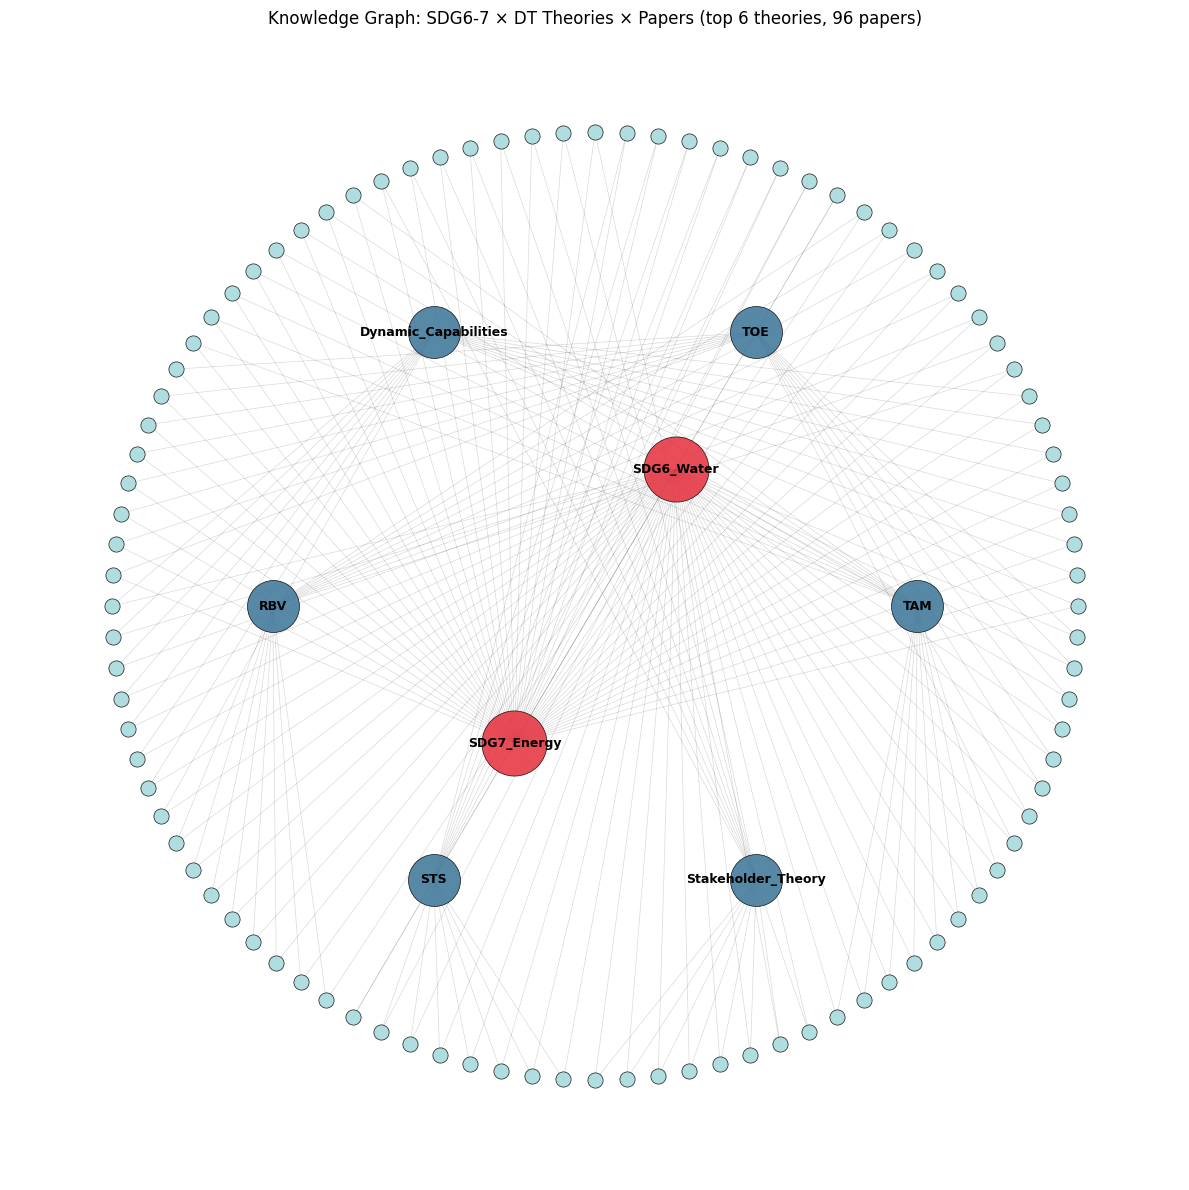

Saved: /content/drive/MyDrive/Colab Notebooks/SDG6-7/outputs/fig_A_knowledge_graph_consolidated.png
Nodes: 104  Edges: 192


In [20]:
# ============================================================
# CELL A — CONSOLIDATED PUBLICATION KNOWLEDGE GRAPH
# Replaces redundant Cells 42, 44, 55, 67 from the original notebook.
# Single 3-layer KG with: top theories only, sampled papers, SDG anchors.
# ============================================================

import os, pandas as pd, numpy as np
import networkx as nx
import matplotlib.pyplot as plt

df_master = pd.read_csv(os.path.join(RESULT_PATH, "df_master.csv"))

# Keep only top-N theories for legibility
TOP_N_THEORIES = 6
top_theories = df_master["dominant_dt_theory"].value_counts().head(TOP_N_THEORIES).index.tolist()
df = df_master[df_master["dominant_dt_theory"].isin(top_theories)].copy()

# Sample papers per (SDG, theory) cell to balance the graph
SAMPLE_PER_CELL = 8
df = (df.groupby(["dominant_sdg","dominant_dt_theory"], group_keys=False)
        .apply(lambda g: g.sample(min(SAMPLE_PER_CELL, len(g)), random_state=42)))

G = nx.Graph()
for _, r in df.iterrows():
    p = "P|" + str(r["paper_id"])
    t = "T|" + r["dominant_dt_theory"]
    s = "S|" + r["dominant_sdg"]
    G.add_node(p, type="paper")
    G.add_node(t, type="theory")
    G.add_node(s, type="sdg")
    G.add_edge(p, t); G.add_edge(p, s)

# Layout: shell layout with SDGs inner, theories middle, papers outer
shells = [
    [n for n in G.nodes if G.nodes[n]["type"]=="sdg"],
    [n for n in G.nodes if G.nodes[n]["type"]=="theory"],
    [n for n in G.nodes if G.nodes[n]["type"]=="paper"],
]
pos = nx.shell_layout(G, nlist=shells)

color_map = {"sdg":"#E63946","theory":"#457B9D","paper":"#A8DADC"}
size_map  = {"sdg":2200,    "theory":1400,      "paper":120}

plt.figure(figsize=(12,12))
for ntype in ["paper","theory","sdg"]:
    nodes = [n for n in G.nodes if G.nodes[n]["type"]==ntype]
    nx.draw_networkx_nodes(G, pos, nodelist=nodes,
                           node_color=color_map[ntype],
                           node_size=size_map[ntype],
                           edgecolors="black", linewidths=0.5, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.5)

# Label only theories and SDGs
labels = {n: n.split("|",1)[1] for n in G.nodes if G.nodes[n]["type"] in ["theory","sdg"]}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight="bold")

plt.title(f"Knowledge Graph: SDG6-7 × DT Theories × Papers (top {TOP_N_THEORIES} theories, {len(df)} papers)",
          fontsize=12)
plt.axis("off"); plt.tight_layout()
out = os.path.join(RESULT_PATH, "fig_A_knowledge_graph_consolidated.png")
plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
print(f"Saved: {out}")
print(f"Nodes: {G.number_of_nodes()}  Edges: {G.number_of_edges()}")


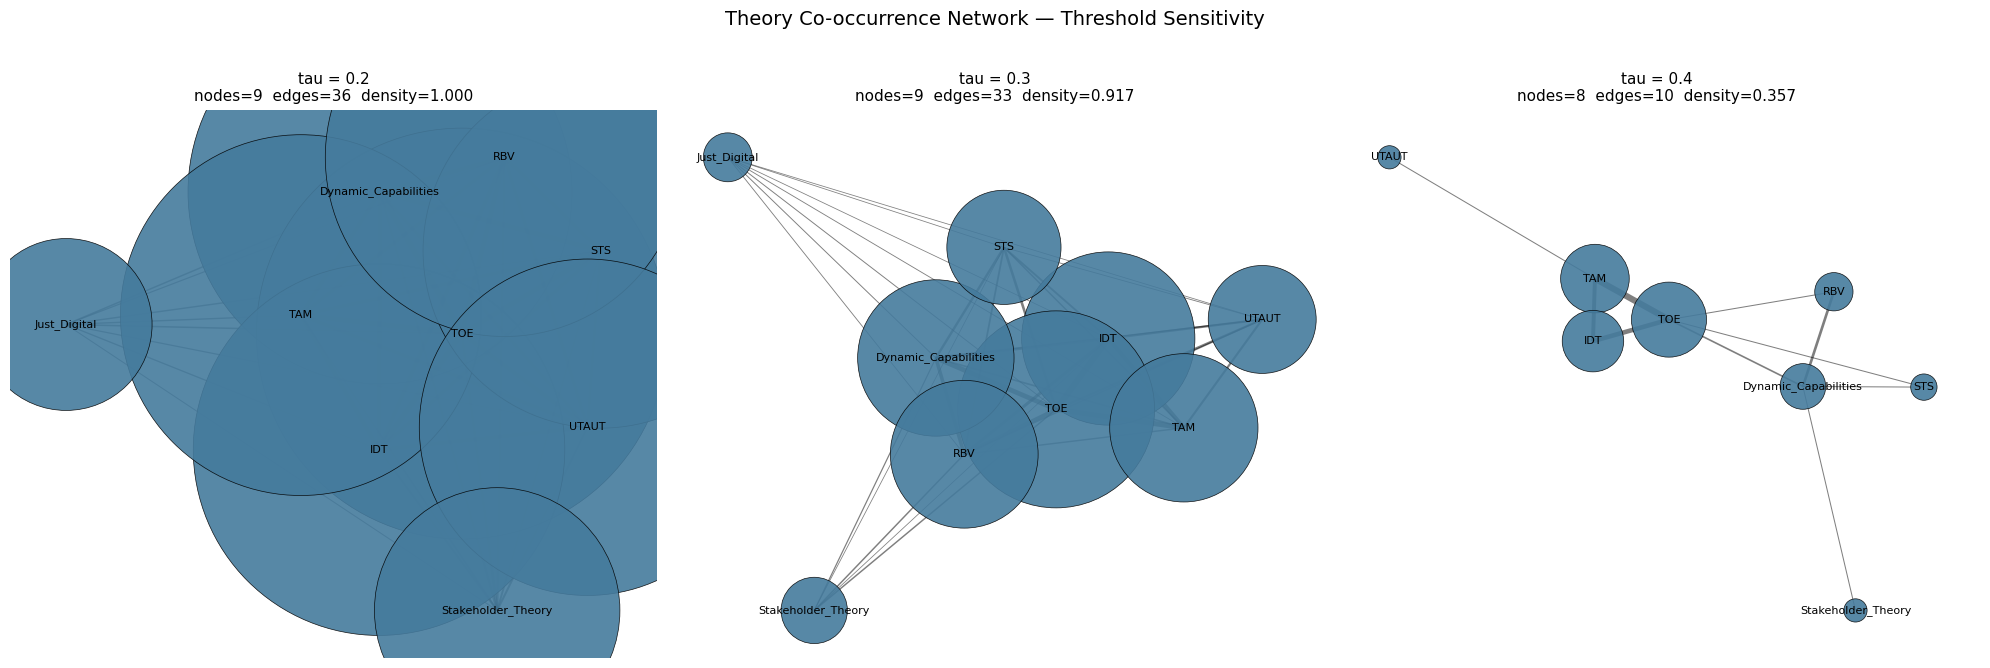

Saved: /content/drive/MyDrive/Colab Notebooks/SDG6-7/outputs/fig_B_threshold_sensitivity.png
   threshold  nodes  edges  density
0        0.2      9     36   1.0000
1        0.3      9     33   0.9167
2        0.4      8     10   0.3571


In [21]:
# ============================================================
# CELL B — THRESHOLD SENSITIVITY GRID (R4)
# Shows theory co-occurrence network at three thresholds.
# Demonstrates structural robustness (or fragility) to choice of tau.
# ============================================================

import os, itertools, pandas as pd, numpy as np
import networkx as nx
import matplotlib.pyplot as plt

df_theory = pd.read_csv(os.path.join(RESULT_PATH, "df_theory_similarity.csv"))
theory_cols = [c for c in df_theory.columns if c not in ["paper_id","dominant_dt_theory"]]

THRESHOLDS = [0.20, 0.30, 0.40]

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

stats_rows = []
for ax, tau in zip(axes, THRESHOLDS):
    edges = []
    for _, row in df_theory.iterrows():
        active = [t for t in theory_cols if row[t] >= tau]
        for a, b in itertools.combinations(active, 2):
            edges.append(tuple(sorted([a,b])))

    if not edges:
        ax.text(0.5, 0.5, f"No edges at tau={tau}", ha="center", va="center")
        ax.set_title(f"tau = {tau}")
        ax.axis("off")
        stats_rows.append({"threshold": tau, "nodes": 0, "edges": 0, "density": 0.0})
        continue

    edge_counts = pd.Series(edges).value_counts()
    G = nx.Graph()
    for (a,b), w in edge_counts.items():
        G.add_edge(a, b, weight=int(w))

    pos = nx.spring_layout(G, seed=42, k=0.8)
    weights = [G[u][v]["weight"] for u,v in G.edges()]
    wmax = max(weights) if weights else 1
    widths = [0.5 + 4*(w/wmax) for w in weights]

    deg = dict(G.degree(weight="weight"))
    sizes = [200 + 80*deg.get(n,0) for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color="#457B9D",
                           edgecolors="black", linewidths=0.5, alpha=0.9, ax=ax)
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.5, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

    density = nx.density(G)
    ax.set_title(f"tau = {tau}\nnodes={G.number_of_nodes()}  edges={G.number_of_edges()}  density={density:.3f}",
                 fontsize=11)
    ax.axis("off")
    stats_rows.append({"threshold": tau, "nodes": G.number_of_nodes(),
                       "edges": G.number_of_edges(), "density": round(density,4)})

plt.suptitle("Theory Co-occurrence Network — Threshold Sensitivity", fontsize=14, y=1.02)
plt.tight_layout()
out = os.path.join(RESULT_PATH, "fig_B_threshold_sensitivity.png")
plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()

pd.DataFrame(stats_rows).to_csv(os.path.join(RESULT_PATH, "fig_B_sensitivity_stats.csv"), index=False)
print(f"Saved: {out}")
print(pd.DataFrame(stats_rows))


Outcome counts (computed from df_master):
dominant_sdg    SDG6_Water  SDG7_Energy
outcome_token                          
access                 156          215
efficiency             143          218
equity                  18           36
governance              62          133
inequality              10           29
productivity            60           82
quality                159          185
resilience              64           94
sustainability         133          195


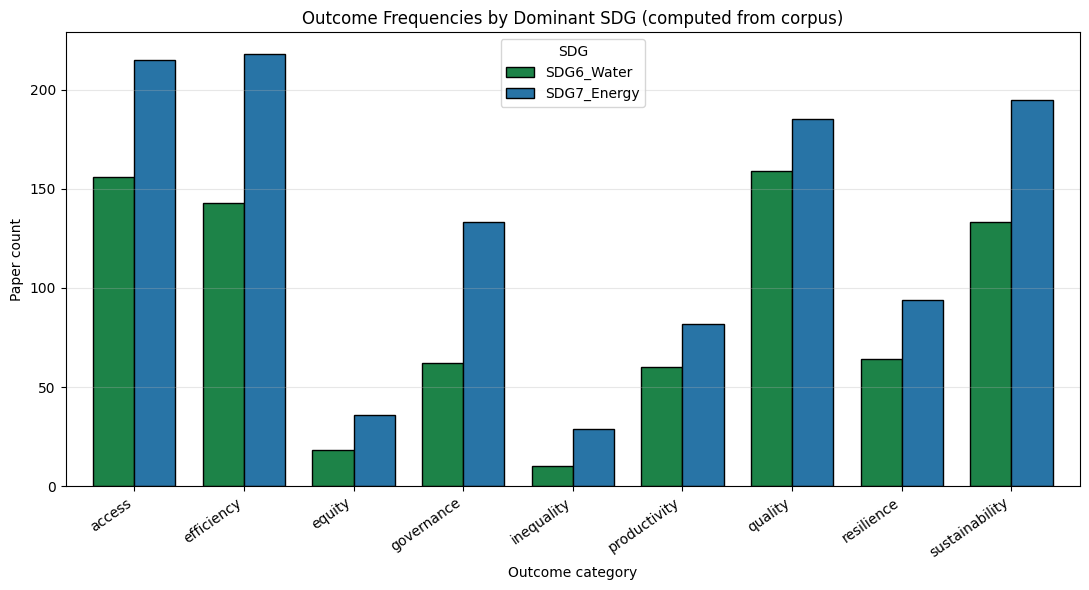

Saved: /content/drive/MyDrive/Colab Notebooks/SDG6-7/outputs/fig_C_outcomes_by_sdg.png


In [22]:
# ============================================================
# CELL C — OUTCOME COUNTERS RECOMPUTED FROM DATA (R3)
# Replaces hardcoded literals in original Cell 62.
# Outputs both the table and the SDG-outcome bar chart.
# ============================================================

import os, pandas as pd, matplotlib.pyplot as plt

df_master = pd.read_csv(os.path.join(RESULT_PATH, "df_master.csv"))

# Explode the outcomes_all field
df = df_master.copy()
df["outcomes_list"] = df["outcomes_all"].fillna("").apply(lambda s: [x for x in s.split("|") if x])
df_exp = df.explode("outcomes_list").rename(columns={"outcomes_list":"outcome_token"})
df_exp = df_exp[df_exp["outcome_token"].notna() & (df_exp["outcome_token"]!="")]

# Outcome × SDG counts
ct = pd.crosstab(df_exp["outcome_token"], df_exp["dominant_sdg"])
ct.to_csv(os.path.join(RESULT_PATH, "fig_C_outcome_counts.csv"))
print("Outcome counts (computed from df_master):")
print(ct)

fig, ax = plt.subplots(figsize=(11, 6))
ct.plot(kind="bar", ax=ax, color=["#1D8348", "#2874A6"], edgecolor="black", width=0.75)
ax.set_title("Outcome Frequencies by Dominant SDG (computed from corpus)", fontsize=12)
ax.set_xlabel("Outcome category"); ax.set_ylabel("Paper count")
ax.set_xticklabels(ct.index, rotation=35, ha="right")
ax.legend(title="SDG"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
out = os.path.join(RESULT_PATH, "fig_C_outcomes_by_sdg.png")
plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
print(f"Saved: {out}")


Bridge papers (|margin| < 0.05): 102 of 457 (22.3%)


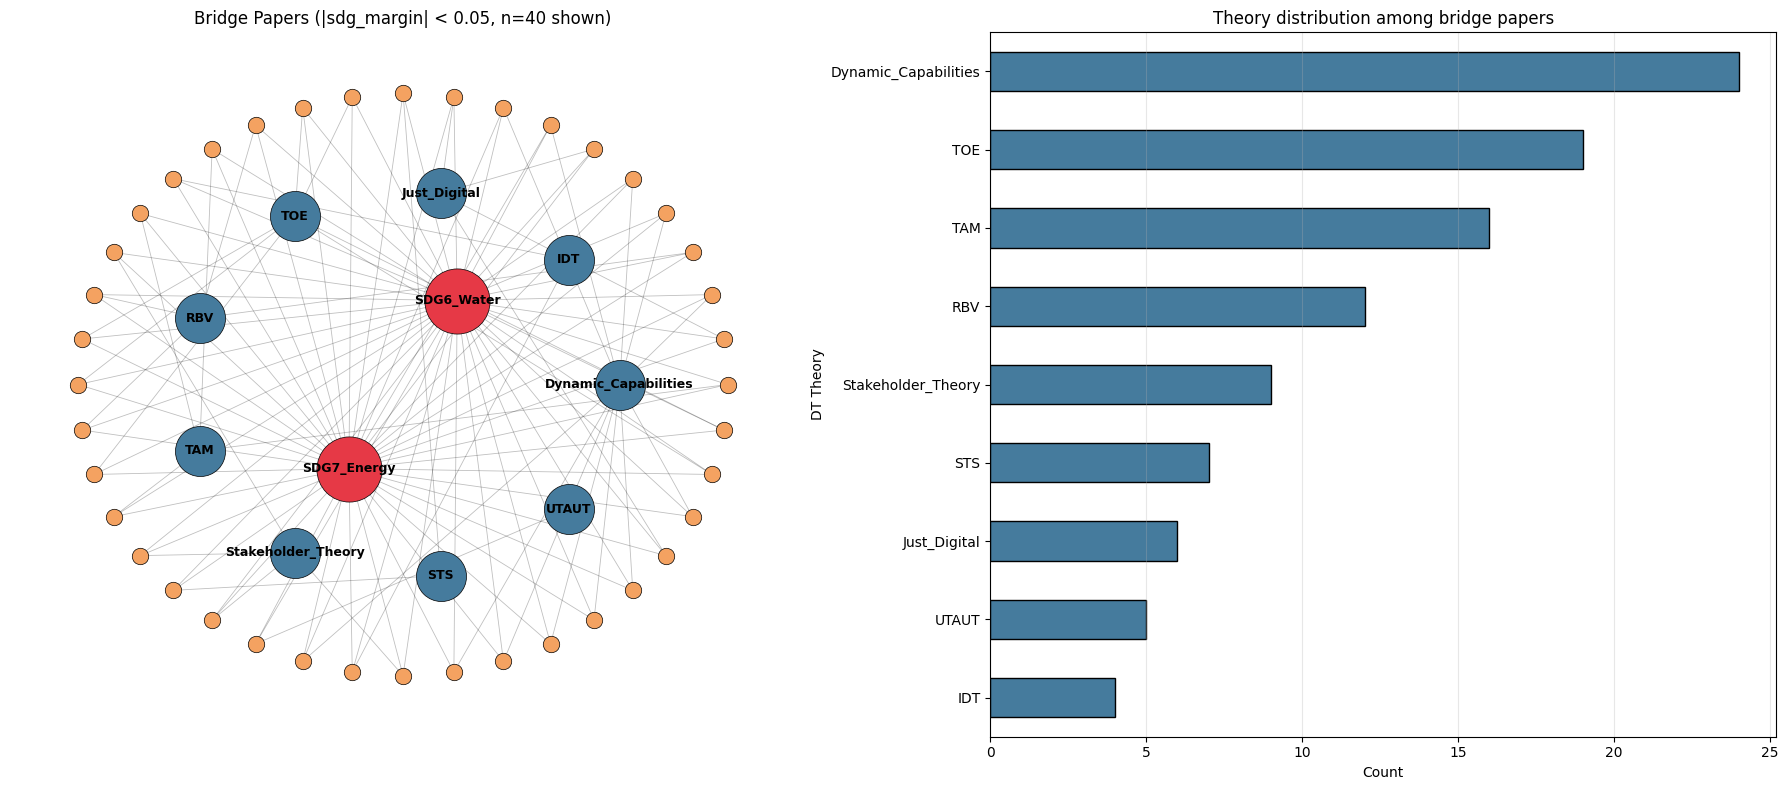

Saved: /content/drive/MyDrive/Colab Notebooks/SDG6-7/outputs/fig_D_bridge_structure_unified.png


In [23]:
# ============================================================
# CELL D — UNIFIED BRIDGE STRUCTURE FIGURE (R1+R5)
# Replaces Cells 47, 52, 54 from original notebook.
# Two-panel: (left) bridge papers in 3-layer view, (right) bridge degree dist.
# ============================================================

import os, pandas as pd, numpy as np
import networkx as nx
import matplotlib.pyplot as plt

df_master = pd.read_csv(os.path.join(RESULT_PATH, "df_master.csv"))

BRIDGE_THRESHOLD = 0.05
df_bridge = df_master[df_master["sdg_margin"].abs() < BRIDGE_THRESHOLD].copy()
print(f"Bridge papers (|margin| < {BRIDGE_THRESHOLD}): {len(df_bridge)} of {len(df_master)} "
      f"({100*len(df_bridge)/len(df_master):.1f}%)")

if len(df_bridge) == 0:
    print("No bridge papers at this threshold. Try BRIDGE_THRESHOLD = 0.10.")
else:
    sample_n = min(40, len(df_bridge))
    df_b = df_bridge.sample(sample_n, random_state=42)

    G = nx.Graph()
    for _, r in df_b.iterrows():
        p = "P|" + str(r["paper_id"])
        t = "T|" + r["dominant_dt_theory"]
        # bridges connect to BOTH SDGs (they sit at boundary)
        G.add_node(p, type="paper")
        G.add_node(t, type="theory")
        G.add_node("S|SDG6_Water",  type="sdg")
        G.add_node("S|SDG7_Energy", type="sdg")
        G.add_edge(p, t)
        G.add_edge(p, "S|SDG6_Water")
        G.add_edge(p, "S|SDG7_Energy")

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Panel 1: bridge graph
    shells = [
        [n for n in G.nodes if G.nodes[n]["type"]=="sdg"],
        [n for n in G.nodes if G.nodes[n]["type"]=="theory"],
        [n for n in G.nodes if G.nodes[n]["type"]=="paper"],
    ]
    pos = nx.shell_layout(G, nlist=shells)
    cmap = {"sdg":"#E63946","theory":"#457B9D","paper":"#F4A261"}
    smap = {"sdg":2200,"theory":1300,"paper":140}

    for ntype in ["paper","theory","sdg"]:
        nodes = [n for n in G.nodes if G.nodes[n]["type"]==ntype]
        nx.draw_networkx_nodes(G, pos, nodelist=nodes,
                               node_color=cmap[ntype], node_size=smap[ntype],
                               edgecolors="black", linewidths=0.5, ax=axes[0])
    nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.6, ax=axes[0])
    labels = {n: n.split("|",1)[1] for n in G.nodes if G.nodes[n]["type"] in ["theory","sdg"]}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight="bold", ax=axes[0])
    axes[0].set_title(f"Bridge Papers (|sdg_margin| < {BRIDGE_THRESHOLD}, n={sample_n} shown)", fontsize=12)
    axes[0].axis("off")

    # Panel 2: bridge theory distribution
    bridge_theory_counts = df_bridge["dominant_dt_theory"].value_counts()
    bridge_theory_counts.plot(kind="barh", ax=axes[1], color="#457B9D", edgecolor="black")
    axes[1].set_title("Theory distribution among bridge papers", fontsize=12)
    axes[1].set_xlabel("Count"); axes[1].set_ylabel("DT Theory")
    axes[1].grid(axis="x", alpha=0.3)
    axes[1].invert_yaxis()

    plt.tight_layout()
    out = os.path.join(RESULT_PATH, "fig_D_bridge_structure_unified.png")
    plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
    print(f"Saved: {out}")


## Additions Block (E-L) — 7 new publication figures

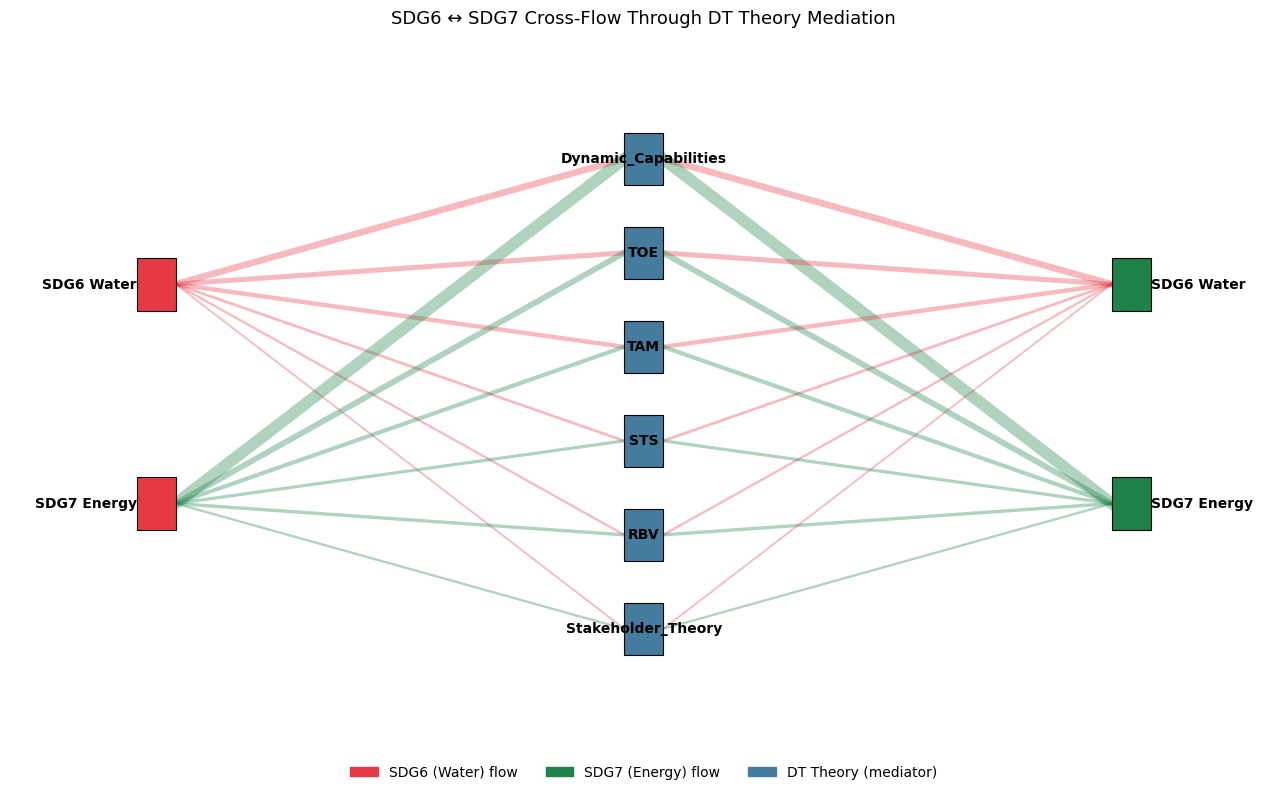

Saved: /content/drive/MyDrive/Colab Notebooks/SDG6-7/outputs/fig_E_sdg_crossflow_sankey.png


In [24]:
# ============================================================
# CELL E — SDG6 ↔ SDG7 CROSS-FLOW (Theory mediation)
# Implemented as a 3-column flow diagram (matplotlib Sankey-style).
# Directly answers the stated RQ: how does DT mediate SDG6 ↔ SDG7?
# ============================================================

import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_master = pd.read_csv(os.path.join(RESULT_PATH, "df_master.csv"))

# Build the two flow tables
TOP_N = 6
top_theories = df_master["dominant_dt_theory"].value_counts().head(TOP_N).index.tolist()
df = df_master[df_master["dominant_dt_theory"].isin(top_theories)]

flow_in  = df.groupby(["dominant_sdg","dominant_dt_theory"]).size().reset_index(name="w")
# For "out" we use the same table inverted to show theory -> SDG flow

fig, ax = plt.subplots(figsize=(13, 8))

sdgs_left  = ["SDG6_Water", "SDG7_Energy"]
theories   = top_theories
sdgs_right = ["SDG6_Water", "SDG7_Energy"]

x_left, x_mid, x_right = 0.0, 0.5, 1.0

# Vertical positions
def y_positions(items, total_height=1.0):
    n = len(items); gap = total_height/(n+1)
    return {item: total_height - (i+1)*gap for i, item in enumerate(items)}

y_left  = y_positions(sdgs_left)
y_mid   = y_positions(theories)
y_right = y_positions(sdgs_right)

# Draw nodes
node_w = 0.04
def draw_node(x, y, label, color, ax, anchor="center"):
    rect = mpatches.Rectangle((x-node_w/2, y-0.04), node_w, 0.08,
                              facecolor=color, edgecolor="black", linewidth=0.8, zorder=3)
    ax.add_patch(rect)
    ha = anchor
    dx = -0.02 if anchor=="right" else (0.02 if anchor=="left" else 0)
    ax.text(x+dx, y, label, ha=ha, va="center", fontsize=10, fontweight="bold", zorder=4)

for s in sdgs_left:
    draw_node(x_left, y_left[s], s.replace("_"," "), "#E63946", ax, anchor="right")
for t in theories:
    draw_node(x_mid, y_mid[t], t, "#457B9D", ax, anchor="center")
for s in sdgs_right:
    draw_node(x_right, y_right[s], s.replace("_"," "), "#1D8348", ax, anchor="left")

# Draw flows: SDG_left -> theory (width = count of papers with that SDG and theory)
max_w = flow_in["w"].max()
for _, r in flow_in.iterrows():
    s, t, w = r["dominant_sdg"], r["dominant_dt_theory"], r["w"]
    if t not in y_mid: continue
    lw = 0.5 + 8*(w/max_w)
    color = "#E63946" if s=="SDG6_Water" else "#1D8348"
    ax.plot([x_left+node_w/2, x_mid-node_w/2],
            [y_left[s], y_mid[t]],
            color=color, alpha=0.35, linewidth=lw, zorder=1)

# Outflow: theory -> SDG_right (same counts since each paper maps theory<->SDG)
flow_out = df.groupby(["dominant_dt_theory","dominant_sdg"]).size().reset_index(name="w")
for _, r in flow_out.iterrows():
    t, s, w = r["dominant_dt_theory"], r["dominant_sdg"], r["w"]
    if t not in y_mid: continue
    lw = 0.5 + 8*(w/max_w)
    color = "#E63946" if s=="SDG6_Water" else "#1D8348"
    ax.plot([x_mid+node_w/2, x_right-node_w/2],
            [y_mid[t], y_right[s]],
            color=color, alpha=0.35, linewidth=lw, zorder=1)

ax.set_xlim(-0.15, 1.15); ax.set_ylim(-0.05, 1.05)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("SDG6 ↔ SDG7 Cross-Flow Through DT Theory Mediation", fontsize=13)
for spine in ax.spines.values(): spine.set_visible(False)

# Legend
legend_handles = [
    mpatches.Patch(color="#E63946", label="SDG6 (Water) flow"),
    mpatches.Patch(color="#1D8348", label="SDG7 (Energy) flow"),
    mpatches.Patch(color="#457B9D", label="DT Theory (mediator)"),
]
ax.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.05),
          ncol=3, frameon=False, fontsize=10)

plt.tight_layout()
out = os.path.join(RESULT_PATH, "fig_E_sdg_crossflow_sankey.png")
plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
print(f"Saved: {out}")


Full graph: 457 nodes, 2699 edges
LCC:        381 nodes, 2695 edges


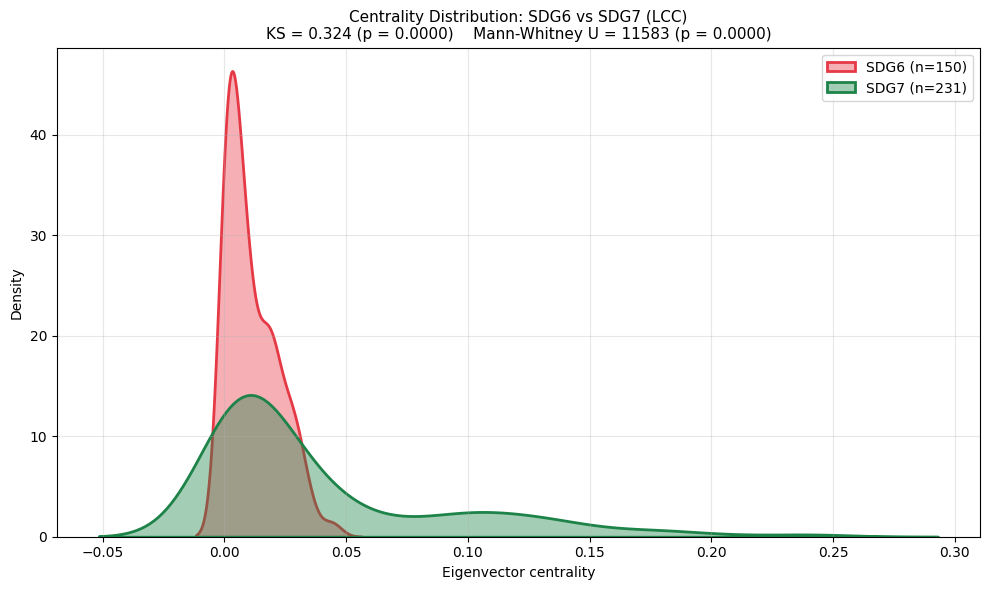

Saved: /content/drive/MyDrive/Colab Notebooks/SDG6-7/outputs/fig_F_centrality_kde_ks.png


In [25]:
# ============================================================
# CELL F — CENTRALITY DISTRIBUTION OVERLAY + KS TEST
# Builds the paper-similarity network, computes eigenvector centrality
# per paper, and compares SDG6 vs SDG7 centrality distributions with
# Kolmogorov-Smirnov and Mann-Whitney tests.
# ============================================================

import os, pandas as pd, numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.metrics.pairwise import cosine_similarity

df_docs   = pd.read_csv(os.path.join(RESULT_PATH, "df_documents_full.csv"))
df_master = pd.read_csv(os.path.join(RESULT_PATH, "df_master.csv"))
emb       = np.load(os.path.join(RESULT_PATH, "doc_embeddings.npy"))

df = df_docs.merge(df_master[["paper_id","dominant_sdg"]], on="paper_id").reset_index(drop=True)

# Build similarity network on largest connected component
SIM_THRESHOLD = 0.55
sim = cosine_similarity(emb)
np.fill_diagonal(sim, 0)

G = nx.Graph()
G.add_nodes_from(df["paper_id"].tolist())
n = len(df)
for i in range(n):
    for j in range(i+1, n):
        if sim[i,j] >= SIM_THRESHOLD:
            G.add_edge(df["paper_id"].iloc[i], df["paper_id"].iloc[j], weight=float(sim[i,j]))

# Restrict to LCC
if G.number_of_edges() > 0:
    lcc_nodes = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(lcc_nodes).copy()
else:
    G_lcc = G

print(f"Full graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"LCC:        {G_lcc.number_of_nodes()} nodes, {G_lcc.number_of_edges()} edges")

# Eigenvector centrality
try:
    cent = nx.eigenvector_centrality_numpy(G_lcc, weight="weight")
except Exception:
    cent = nx.degree_centrality(G_lcc)
    print("Fell back to degree centrality (eigenvector failed)")

df_cent = pd.DataFrame({"paper_id": list(cent.keys()), "centrality": list(cent.values())})
df_cent = df_cent.merge(df[["paper_id","dominant_sdg"]], on="paper_id")
df_cent.to_csv(os.path.join(RESULT_PATH, "fig_F_centrality_per_paper.csv"), index=False)

c6 = df_cent[df_cent["dominant_sdg"]=="SDG6_Water"]["centrality"].values
c7 = df_cent[df_cent["dominant_sdg"]=="SDG7_Energy"]["centrality"].values

if len(c6) > 5 and len(c7) > 5:
    ks_stat, ks_p = ks_2samp(c6, c7)
    mw_stat, mw_p = mannwhitneyu(c6, c7, alternative="two-sided")
else:
    ks_stat=ks_p=mw_stat=mw_p=float("nan")

fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(c6, ax=ax, fill=True, color="#E63946", alpha=0.4, label=f"SDG6 (n={len(c6)})", linewidth=2)
sns.kdeplot(c7, ax=ax, fill=True, color="#1D8348", alpha=0.4, label=f"SDG7 (n={len(c7)})", linewidth=2)
ax.set_xlabel("Eigenvector centrality"); ax.set_ylabel("Density")
ax.set_title(f"Centrality Distribution: SDG6 vs SDG7 (LCC)\n"
             f"KS = {ks_stat:.3f} (p = {ks_p:.4f})    "
             f"Mann-Whitney U = {mw_stat:.0f} (p = {mw_p:.4f})", fontsize=11)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
out = os.path.join(RESULT_PATH, "fig_F_centrality_kde_ks.png")
plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
print(f"Saved: {out}")

# Persist test results
pd.DataFrame([{"ks_stat":ks_stat,"ks_p":ks_p,"mw_u":mw_stat,"mw_p":mw_p,
               "n_sdg6":len(c6),"n_sdg7":len(c7),
               "mean_sdg6":float(np.mean(c6)) if len(c6) else np.nan,
               "mean_sdg7":float(np.mean(c7)) if len(c7) else np.nan}]
            ).to_csv(os.path.join(RESULT_PATH, "fig_F_test_results.csv"), index=False)


Max core number: 14


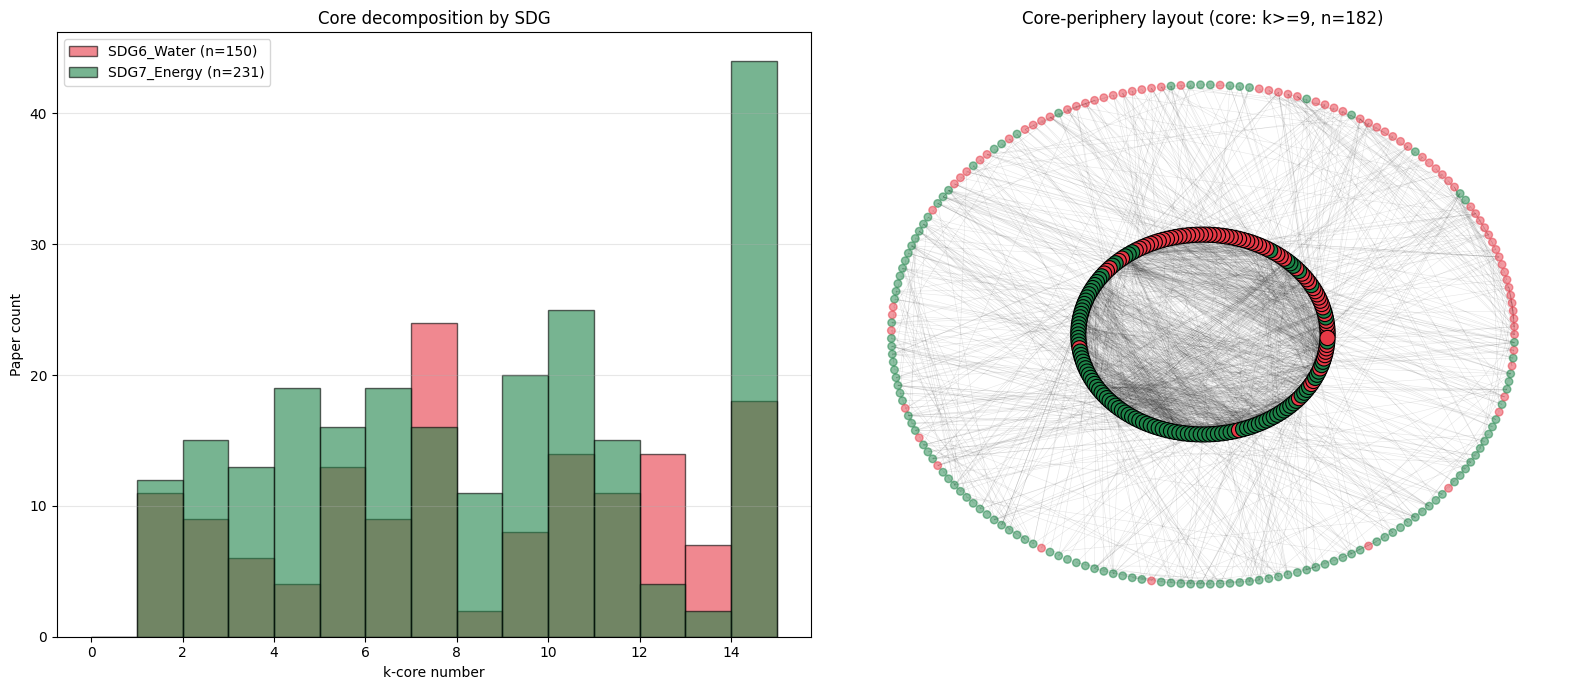

Saved: /content/drive/MyDrive/Colab Notebooks/SDG6-7/outputs/fig_H_core_periphery.png


In [26]:
# ============================================================
# CELL H — CORE-PERIPHERY DECOMPOSITION
# Identifies core vs peripheral papers via k-core decomposition
# on the paper-similarity LCC. Mirrors the SDG 5-8 protocol.
# ============================================================

import os, pandas as pd, numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

df_docs   = pd.read_csv(os.path.join(RESULT_PATH, "df_documents_full.csv"))
df_master = pd.read_csv(os.path.join(RESULT_PATH, "df_master.csv"))
emb       = np.load(os.path.join(RESULT_PATH, "doc_embeddings.npy"))
df = df_docs.merge(df_master[["paper_id","dominant_sdg"]], on="paper_id").reset_index(drop=True)

SIM_THRESHOLD = 0.55
sim = cosine_similarity(emb); np.fill_diagonal(sim, 0)
G = nx.Graph()
G.add_nodes_from(df["paper_id"].tolist())
n = len(df)
for i in range(n):
    for j in range(i+1, n):
        if sim[i,j] >= SIM_THRESHOLD:
            G.add_edge(df["paper_id"].iloc[i], df["paper_id"].iloc[j])
if G.number_of_edges() > 0:
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

# k-core decomposition
core_numbers = nx.core_number(G)
df_core = pd.DataFrame({"paper_id": list(core_numbers.keys()),
                        "core_number": list(core_numbers.values())})
df_core = df_core.merge(df[["paper_id","dominant_sdg"]], on="paper_id")
df_core.to_csv(os.path.join(RESULT_PATH, "fig_H_core_decomposition.csv"), index=False)

max_k = df_core["core_number"].max()
print(f"Max core number: {max_k}")

# Two-panel figure
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: histogram of core numbers by SDG
for sdg, color in [("SDG6_Water","#E63946"),("SDG7_Energy","#1D8348")]:
    sub = df_core[df_core["dominant_sdg"]==sdg]
    axes[0].hist(sub["core_number"], bins=range(0, max_k+2), alpha=0.6,
                 label=f"{sdg} (n={len(sub)})", color=color, edgecolor="black")
axes[0].set_xlabel("k-core number"); axes[0].set_ylabel("Paper count")
axes[0].set_title("Core decomposition by SDG", fontsize=12)
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

# Right: network with core-shell layout
top_k_threshold = max(1, int(max_k * 0.7))  # top 30% as "core"
core_nodes = [n for n,k in core_numbers.items() if k >= top_k_threshold]
periph_nodes = [n for n in G.nodes if n not in core_nodes]

pos = {}
import math
for i, node in enumerate(core_nodes):
    angle = 2*math.pi*i/max(1,len(core_nodes))
    pos[node] = (0.4*math.cos(angle), 0.4*math.sin(angle))
for i, node in enumerate(periph_nodes):
    angle = 2*math.pi*i/max(1,len(periph_nodes))
    pos[node] = (1.0*math.cos(angle), 1.0*math.sin(angle))

sdg_lookup = dict(zip(df_core["paper_id"], df_core["dominant_sdg"]))
node_colors = ["#E63946" if sdg_lookup.get(n)=="SDG6_Water" else "#1D8348" for n in G.nodes]

nx.draw_networkx_edges(G, pos, alpha=0.1, width=0.4, ax=axes[1])
nx.draw_networkx_nodes(G, pos, nodelist=core_nodes,
                       node_color=[node_colors[list(G.nodes).index(n)] for n in core_nodes],
                       node_size=120, edgecolors="black", linewidths=0.8, ax=axes[1])
nx.draw_networkx_nodes(G, pos, nodelist=periph_nodes,
                       node_color=[node_colors[list(G.nodes).index(n)] for n in periph_nodes],
                       node_size=30, alpha=0.5, ax=axes[1])
axes[1].set_title(f"Core-periphery layout (core: k>={top_k_threshold}, n={len(core_nodes)})", fontsize=12)
axes[1].axis("off")

plt.tight_layout()
out = os.path.join(RESULT_PATH, "fig_H_core_periphery.png")
plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
print(f"Saved: {out}")


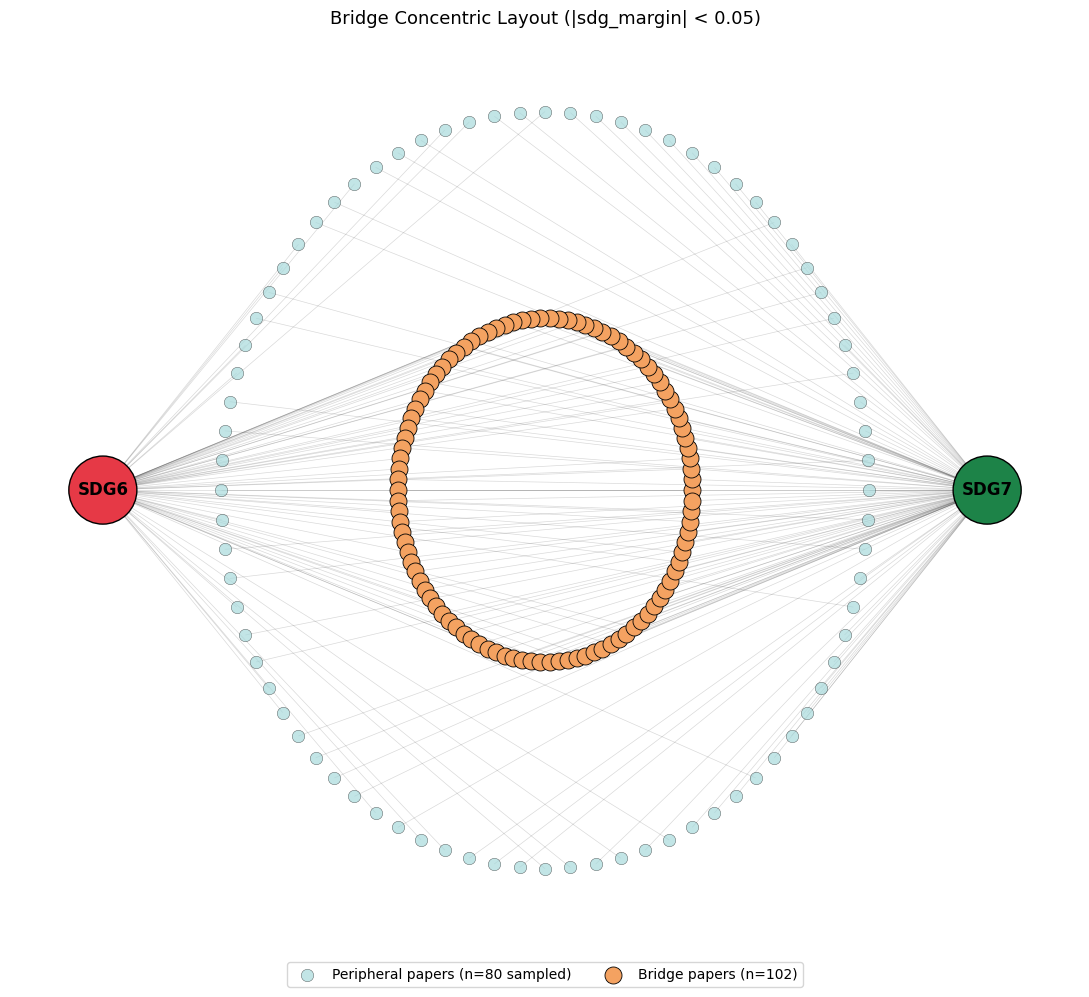

Saved: /content/drive/MyDrive/Colab Notebooks/SDG6-7/outputs/fig_I_bridge_concentric.png
Total bridge papers in corpus: 102


In [27]:
# ============================================================
# CELL I — BRIDGE CONCENTRIC LAYOUT (replaces hairball)
# Inner ring: bridge papers; outer ring: non-bridge; SDGs as anchors.
# ============================================================

import os, pandas as pd, numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import math

df_master = pd.read_csv(os.path.join(RESULT_PATH, "df_master.csv"))

BRIDGE_TAU = 0.05
df_master["is_bridge"] = (df_master["sdg_margin"].abs() < BRIDGE_TAU).astype(int)

SAMPLE_NON_BRIDGE = 80
df_b  = df_master[df_master["is_bridge"]==1]
df_nb = df_master[df_master["is_bridge"]==0].sample(min(SAMPLE_NON_BRIDGE, (df_master["is_bridge"]==0).sum()), random_state=42)

G = nx.Graph()
for _, r in pd.concat([df_b, df_nb]).iterrows():
    p = "P|" + str(r["paper_id"])
    G.add_node(p, type="paper", bridge=int(r["is_bridge"]))
    G.add_edge(p, "S|"+r["dominant_sdg"])
G.add_node("S|SDG6_Water",  type="sdg")
G.add_node("S|SDG7_Energy", type="sdg")

# Concentric layout
pos = {"S|SDG6_Water":(-1.5, 0), "S|SDG7_Energy":(1.5, 0)}
bridge_nodes  = [n for n in G.nodes if G.nodes[n].get("type")=="paper" and G.nodes[n].get("bridge")==1]
periph_nodes  = [n for n in G.nodes if G.nodes[n].get("type")=="paper" and G.nodes[n].get("bridge")==0]

for i, node in enumerate(bridge_nodes):
    angle = 2*math.pi*i/max(1,len(bridge_nodes))
    pos[node] = (0.5*math.cos(angle), 0.5*math.sin(angle))
for i, node in enumerate(periph_nodes):
    angle = 2*math.pi*i/max(1,len(periph_nodes))
    pos[node] = (1.1*math.cos(angle), 1.1*math.sin(angle))

plt.figure(figsize=(11, 10))
nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.5)
nx.draw_networkx_nodes(G, pos, nodelist=periph_nodes, node_color="#A8DADC",
                       node_size=80, alpha=0.7, edgecolors="black", linewidths=0.3,
                       label=f"Peripheral papers (n={len(periph_nodes)} sampled)")
nx.draw_networkx_nodes(G, pos, nodelist=bridge_nodes, node_color="#F4A261",
                       node_size=150, edgecolors="black", linewidths=0.6,
                       label=f"Bridge papers (n={len(bridge_nodes)})")
nx.draw_networkx_nodes(G, pos, nodelist=["S|SDG6_Water","S|SDG7_Energy"],
                       node_color=["#E63946","#1D8348"], node_size=2400,
                       edgecolors="black", linewidths=1.0)
nx.draw_networkx_labels(G, pos, labels={"S|SDG6_Water":"SDG6","S|SDG7_Energy":"SDG7"},
                        font_size=12, font_weight="bold")

plt.title(f"Bridge Concentric Layout (|sdg_margin| < {BRIDGE_TAU})", fontsize=13)
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=10)
plt.axis("off"); plt.tight_layout()
out = os.path.join(RESULT_PATH, "fig_I_bridge_concentric.png")
plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
print(f"Saved: {out}")
print(f"Total bridge papers in corpus: {len(df_b)}")


Baseline LCC: 381 nodes, 2695 edges
                                scenario      mean    ci_low   ci_high  n_iter
0    Random rewiring (degree-preserving)  0.023371  0.022889  0.023813      30
1                Randomized edge weights  0.002016  0.001497  0.002788      30
2  Shuffled SDG labels (SDG6-7 mean gap)  0.003583  0.001050  0.007216      30


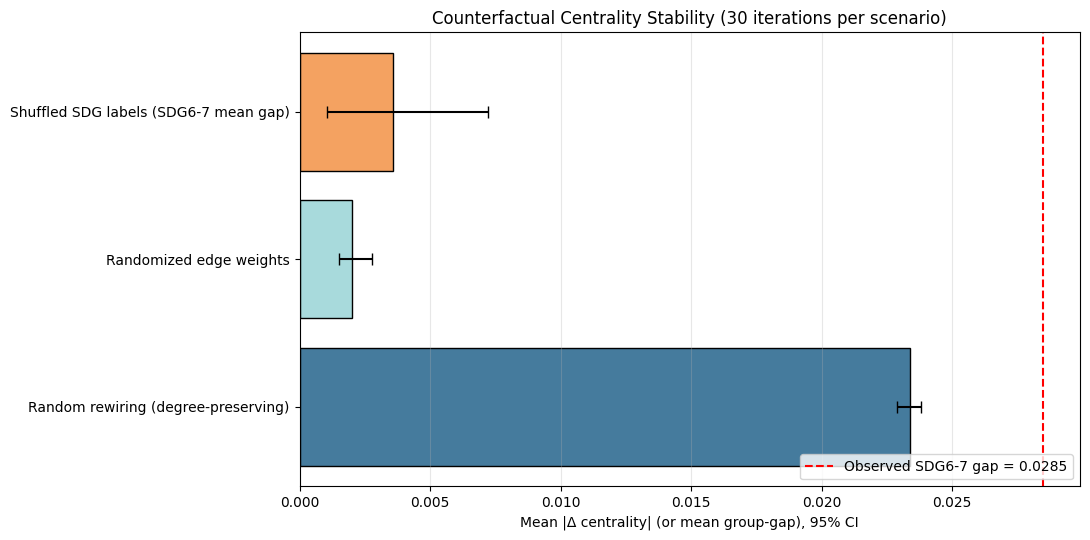

Saved: /content/drive/MyDrive/Colab Notebooks/SDG6-7/outputs/fig_J_counterfactual.png


In [28]:
# ============================================================
# CELL J — COUNTERFACTUAL DELTA-CENTRALITY (30 iterations)
# Embedded computation. Three scenarios:
#   (1) random rewiring (preserves degree sequence)
#   (2) random edge weights
#   (3) shuffled SDG labels
# Each: 30 iterations, compute mean |delta-centrality| with 95% CI.
# ============================================================

import os, pandas as pd, numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

df_docs   = pd.read_csv(os.path.join(RESULT_PATH, "df_documents_full.csv"))
df_master = pd.read_csv(os.path.join(RESULT_PATH, "df_master.csv"))
emb       = np.load(os.path.join(RESULT_PATH, "doc_embeddings.npy"))
df = df_docs.merge(df_master[["paper_id","dominant_sdg"]], on="paper_id").reset_index(drop=True)

SIM_THRESHOLD = 0.55
sim = cosine_similarity(emb); np.fill_diagonal(sim, 0)
G = nx.Graph()
ids = df["paper_id"].tolist()
G.add_nodes_from(ids)
n = len(ids)
for i in range(n):
    for j in range(i+1, n):
        if sim[i,j] >= SIM_THRESHOLD:
            G.add_edge(ids[i], ids[j], weight=float(sim[i,j]))
if G.number_of_edges() > 0:
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

print(f"Baseline LCC: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

def safe_eigen(g, weight=None):
    try:
        return nx.eigenvector_centrality_numpy(g, weight=weight)
    except Exception:
        return nx.degree_centrality(g)

baseline = safe_eigen(G, weight="weight")
nodes_ordered = list(G.nodes())
b_vec = np.array([baseline[n] for n in nodes_ordered])

ITER = 30
np.random.seed(42)

scenarios = {}

# Scenario 1: degree-preserving random rewiring (with safe fallback)
deltas_s1 = []
n_edges = G.number_of_edges()
for it in range(ITER):
    G_rw = G.copy()
    try:
        # Modest swap target with high max_tries; fail-safe fallback below
        target_swaps = max(1, n_edges)
        G_rw = nx.double_edge_swap(G_rw, nswap=target_swaps,
                                   max_tries=target_swaps*20, seed=it)
    except (nx.NetworkXAlgorithmError, nx.NetworkXError):
        # Graph too small/dense for full rewiring; use partial rewiring via random edge swap
        rng = np.random.default_rng(it)
        edges_list = list(G_rw.edges())
        n_swap = min(50, len(edges_list)//2)
        for _ in range(n_swap):
            if len(edges_list) < 2: break
            i1, i2 = rng.choice(len(edges_list), size=2, replace=False)
            (u1,v1), (u2,v2) = edges_list[i1], edges_list[i2]
            if len({u1,v1,u2,v2}) == 4 and not G_rw.has_edge(u1,v2) and not G_rw.has_edge(u2,v1):
                G_rw.remove_edge(u1,v1); G_rw.remove_edge(u2,v2)
                G_rw.add_edge(u1,v2); G_rw.add_edge(u2,v1)
                edges_list = list(G_rw.edges())
    c = safe_eigen(G_rw, weight=None)
    deltas_s1.append(np.mean(np.abs(np.array([c.get(n,0) for n in nodes_ordered]) - b_vec)))
scenarios["Random rewiring (degree-preserving)"] = deltas_s1

# Scenario 2: random edge weights
deltas_s2 = []
for it in range(ITER):
    G_rw = G.copy()
    rng = np.random.default_rng(it)
    for u,v in G_rw.edges():
        G_rw[u][v]["weight"] = float(rng.uniform(SIM_THRESHOLD, 1.0))
    c = safe_eigen(G_rw, weight="weight")
    deltas_s2.append(np.mean(np.abs(np.array([c.get(n,0) for n in nodes_ordered]) - b_vec)))
scenarios["Randomized edge weights"] = deltas_s2

# Scenario 3: shuffled SDG labels — measures whether the topology is SDG-driven
# Effect on centrality is computed by partitioning baseline centrality by shuffled label
# and comparing the SDG6-vs-SDG7 mean gap distribution
true_labels = dict(zip(df["paper_id"], df["dominant_sdg"]))
true_gap = abs(np.mean([baseline[n] for n in nodes_ordered if true_labels.get(n)=="SDG6_Water"]) -
               np.mean([baseline[n] for n in nodes_ordered if true_labels.get(n)=="SDG7_Energy"]))
shuffled_gaps = []
labels_arr = np.array([true_labels.get(n,"unknown") for n in nodes_ordered])
for it in range(ITER):
    rng = np.random.default_rng(100+it)
    perm = rng.permutation(labels_arr)
    g6 = b_vec[perm=="SDG6_Water"]; g7 = b_vec[perm=="SDG7_Energy"]
    if len(g6)>0 and len(g7)>0:
        shuffled_gaps.append(abs(g6.mean() - g7.mean()))
scenarios["Shuffled SDG labels (SDG6-7 mean gap)"] = shuffled_gaps

# Build summary
def ci95(a):
    a = np.asarray(a)
    return float(np.mean(a)), float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))

rows = []
for name, vals in scenarios.items():
    m, lo, hi = ci95(vals)
    rows.append({"scenario": name, "mean": m, "ci_low": lo, "ci_high": hi, "n_iter": len(vals)})
df_cf = pd.DataFrame(rows)
df_cf.to_csv(os.path.join(RESULT_PATH, "fig_J_counterfactual_results.csv"), index=False)
print(df_cf)

# Add reference line for true SDG gap
fig, ax = plt.subplots(figsize=(11, 5.5))
y_pos = np.arange(len(df_cf))
ax.barh(y_pos, df_cf["mean"], xerr=[df_cf["mean"]-df_cf["ci_low"], df_cf["ci_high"]-df_cf["mean"]],
        color=["#457B9D","#A8DADC","#F4A261"], edgecolor="black", capsize=4)
ax.axvline(true_gap, color="red", linestyle="--", linewidth=1.5,
           label=f"Observed SDG6-7 gap = {true_gap:.4f}")
ax.set_yticks(y_pos); ax.set_yticklabels(df_cf["scenario"])
ax.set_xlabel("Mean |Δ centrality| (or mean group-gap), 95% CI")
ax.set_title(f"Counterfactual Centrality Stability ({ITER} iterations per scenario)", fontsize=12)
ax.legend(loc="lower right"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
out = os.path.join(RESULT_PATH, "fig_J_counterfactual.png")
plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
print(f"Saved: {out}")


Contingency table shape after cleaning: (9, 4)
Total observations:                     178

outcome      access  efficiency  governance  quality
method                                              
case study        6           0           0        0
experiment        3           0           0        0
interview         3           0           0        0
qualitative       5           0           0        0
regression       44           5           0        1
review           12           1           0        0
sem              77           5           0        1
simulation        1           0           0        0
survey           12           1           1        0

chi-square not run (>50% zero cells)


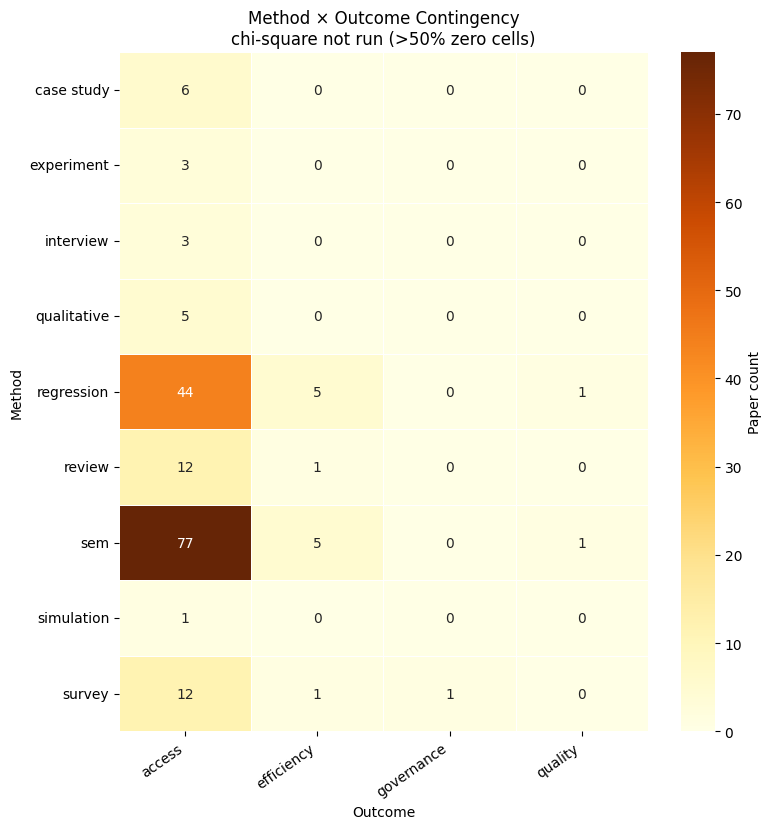


Saved: /content/drive/MyDrive/Colab Notebooks/SDG6-7/outputs/fig_K_method_outcome_mosaic.png


In [29]:
# ============================================================
# CELL K — METHOD × OUTCOME CONTINGENCY MOSAIC (PATCHED)
# Fixed: drop zero-marginal rows/cols before chi-square,
# fall back to Fisher exact for 2x2, report counts only if neither viable.
# ============================================================

import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact

df_master = pd.read_csv(os.path.join(RESULT_PATH, "df_master.csv"))

ct = pd.crosstab(df_master["method"], df_master["outcome"])

# Drop "unknown" rows and columns
ct = ct.drop(index=[i for i in ["unknown"] if i in ct.index], errors="ignore")
ct = ct.drop(columns=[c for c in ["unknown"] if c in ct.columns], errors="ignore")

# Drop zero-marginal rows and columns (these break chi-square)
ct = ct.loc[ct.sum(axis=1) > 0, ct.sum(axis=0) > 0]

print(f"Contingency table shape after cleaning: {ct.shape}")
print(f"Total observations:                     {ct.values.sum()}")
print()
print(ct)

if ct.size == 0 or ct.shape[0] < 2 or ct.shape[1] < 2:
    print("\nTable too small for an independence test (need at least 2x2).")
    test_label = "no test (table too small)"
elif (ct.values == 0).sum() > 0.5 * ct.size:
    # More than half cells are zero — chi-square unreliable, report descriptively
    test_label = "chi-square not run (>50% zero cells)"
    print(f"\n{test_label}")
else:
    try:
        chi2, p, dof, expected = chi2_contingency(ct)
        # Cramer's V effect size
        n = ct.values.sum()
        cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
        test_label = f"chi^2 = {chi2:.2f}, dof = {dof}, p = {p:.4f}, V = {cramers_v:.3f}"
        print(f"\nChi-square: {test_label}")
    except ValueError as e:
        # Final fallback: Fisher exact for 2x2
        if ct.shape == (2, 2):
            odds, p = fisher_exact(ct.values)
            test_label = f"Fisher exact: OR = {odds:.2f}, p = {p:.4f}"
            print(f"\n{test_label}")
        else:
            test_label = f"chi-square failed ({str(e)[:60]})"
            print(f"\n{test_label}")

# Plot regardless of test outcome (the heatmap itself is informative)
if ct.size > 0:
    fig, ax = plt.subplots(figsize=(max(8, 0.7*ct.shape[1]+5), max(5, 0.6*ct.shape[0]+3)))
    sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrBr",
                cbar_kws={"label": "Paper count"},
                linewidths=0.5, linecolor="white", ax=ax)
    ax.set_title(f"Method × Outcome Contingency\n{test_label}", fontsize=12)
    ax.set_xlabel("Outcome"); ax.set_ylabel("Method")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    out = os.path.join(RESULT_PATH, "fig_K_method_outcome_mosaic.png")
    plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
    ct.to_csv(os.path.join(RESULT_PATH, "fig_K_method_outcome_table.csv"))
    print(f"\nSaved: {out}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


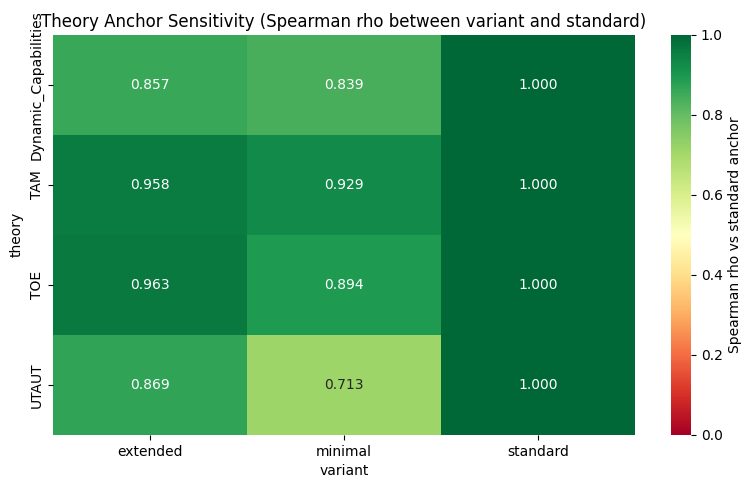

Saved: /content/drive/MyDrive/Colab Notebooks/SDG6-7/outputs/fig_L_anchor_sensitivity.png
                  theory   variant  spearman_rho              p  mean_sim
0                    TAM   minimal      0.929257  6.808052e-199  0.188240
1                    TAM  standard      1.000000   0.000000e+00  0.187639
2                    TAM  extended      0.958240  1.634479e-249  0.188654
3                  UTAUT   minimal      0.713234   3.157706e-72  0.127234
4                  UTAUT  standard      1.000000   0.000000e+00  0.145165
5                  UTAUT  extended      0.869084  3.504734e-141  0.180717
6                    TOE   minimal      0.893935  1.094178e-160  0.247774
7                    TOE  standard      1.000000   0.000000e+00  0.218195
8                    TOE  extended      0.963322  4.424248e-262  0.244498
9   Dynamic_Capabilities   minimal      0.838761  3.367941e-122  0.197582
10  Dynamic_Capabilities  standard      1.000000   0.000000e+00  0.213679
11  Dynamic_Capabiliti

In [30]:
# ============================================================
# CELL L — THEORY ANCHOR SENSITIVITY HEATMAP
# Tests whether dominant-theory assignment is robust to anchor wording.
# For each theory, expand or shrink the anchor text, recompute similarity,
# measure rank correlation with original assignment.
# ============================================================

import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr

df_docs    = pd.read_csv(os.path.join(RESULT_PATH, "df_documents_full.csv"))
df_theory0 = pd.read_csv(os.path.join(RESULT_PATH, "df_theory_similarity.csv"))
emb        = np.load(os.path.join(RESULT_PATH, "doc_embeddings.npy"))

# Three anchor variants per theory: minimal / standard / extended
ANCHOR_VARIANTS = {
    "TAM": {
        "minimal":  "technology acceptance",
        "standard": "technology acceptance usefulness ease of use perceived usefulness perceived ease",
        "extended": "technology acceptance model perceived usefulness perceived ease of use behavioral intention attitude toward use external variables",
    },
    "UTAUT": {
        "minimal":  "performance expectancy",
        "standard": "performance expectancy effort expectancy social influence facilitating conditions",
        "extended": "unified theory acceptance use technology performance expectancy effort expectancy social influence facilitating conditions behavioral intention",
    },
    "TOE": {
        "minimal":  "technology organization environment",
        "standard": "technology organization environment framework adoption context",
        "extended": "technology organization environment framework technological context organizational context environmental context adoption innovation",
    },
    "Dynamic_Capabilities": {
        "minimal":  "dynamic capabilities",
        "standard": "sensing seizing transforming dynamic capabilities reconfiguration",
        "extended": "dynamic capabilities sensing opportunities seizing transforming organizational reconfiguration competitive advantage strategic renewal",
    },
}

model = SentenceTransformer("all-MiniLM-L6-v2")
theory_cols0 = [c for c in df_theory0.columns if c not in ["paper_id","dominant_dt_theory"]]

# For each variant, recompute similarity for that theory only and measure
# rank correlation against the standard assignment
results = []
for theory, variants in ANCHOR_VARIANTS.items():
    if theory not in theory_cols0:
        continue
    standard_scores = df_theory0[theory].values
    for vname, vtext in variants.items():
        v_emb = model.encode([vtext], normalize_embeddings=True)
        v_sim = cosine_similarity(emb, v_emb).ravel()
        rho, p = spearmanr(standard_scores, v_sim)
        results.append({"theory": theory, "variant": vname,
                        "spearman_rho": rho, "p": p,
                        "mean_sim": float(np.mean(v_sim))})

df_sens = pd.DataFrame(results)
df_sens.to_csv(os.path.join(RESULT_PATH, "fig_L_anchor_sensitivity.csv"), index=False)

if len(df_sens) > 0:
    pivot = df_sens.pivot(index="theory", columns="variant", values="spearman_rho")
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
                cbar_kws={"label":"Spearman rho vs standard anchor"}, ax=ax)
    ax.set_title("Theory Anchor Sensitivity (Spearman rho between variant and standard)", fontsize=12)
    plt.tight_layout()
    out = os.path.join(RESULT_PATH, "fig_L_anchor_sensitivity.png")
    plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
    print(f"Saved: {out}")
    print(df_sens)
else:
    print("No anchor sensitivity computed: no overlap between variants and existing theory columns.")


## Cell M — Figure Manifest

In [31]:
# ============================================================
# CELL M — FIGURE MANIFEST
# Auto-generates a manifest CSV listing every figure file written,
# its dimensions, and the data sources it was built from.
# Use this for the manuscript Methods section and reproducibility appendix.
# ============================================================

import os, pandas as pd
from PIL import Image

MANIFEST = [
    {"cell":"A", "file":"fig_A_knowledge_graph_consolidated.png",
     "purpose":"Consolidated 3-layer KG (replaces 4 redundant graphs)",
     "sources":"df_master.csv"},
    {"cell":"B", "file":"fig_B_threshold_sensitivity.png",
     "purpose":"Theory co-occurrence at tau=0.20/0.30/0.40",
     "sources":"df_theory_similarity.csv"},
    {"cell":"C", "file":"fig_C_outcomes_by_sdg.png",
     "purpose":"Outcome counts by SDG (computed, not hardcoded)",
     "sources":"df_master.csv"},
    {"cell":"D", "file":"fig_D_bridge_structure_unified.png",
     "purpose":"Unified bridge figure (replaces 3 near-duplicates)",
     "sources":"df_master.csv"},
    {"cell":"E", "file":"fig_E_sdg_crossflow_sankey.png",
     "purpose":"SDG6 <-> SDG7 cross-flow via DT theory (answers core RQ)",
     "sources":"df_master.csv"},
    {"cell":"F", "file":"fig_F_centrality_kde_ks.png",
     "purpose":"SDG6 vs SDG7 centrality KDE + KS + Mann-Whitney",
     "sources":"df_documents_full.csv, doc_embeddings.npy"},
    {"cell":"H", "file":"fig_H_core_periphery.png",
     "purpose":"k-core decomposition by SDG",
     "sources":"df_documents_full.csv, doc_embeddings.npy"},
    {"cell":"I", "file":"fig_I_bridge_concentric.png",
     "purpose":"Bridge concentric layout (replaces hairball)",
     "sources":"df_master.csv"},
    {"cell":"J", "file":"fig_J_counterfactual.png",
     "purpose":"30-iteration counterfactual delta-centrality with 95% CI",
     "sources":"df_documents_full.csv, doc_embeddings.npy"},
    {"cell":"K", "file":"fig_K_method_outcome_mosaic.png",
     "purpose":"Method x Outcome contingency with chi-square",
     "sources":"df_master.csv"},
    {"cell":"L", "file":"fig_L_anchor_sensitivity.png",
     "purpose":"Theory anchor wording sensitivity (Spearman rho)",
     "sources":"df_documents_full.csv, df_theory_similarity.csv"},
]

rows = []
for entry in MANIFEST:
    path = os.path.join(RESULT_PATH, entry["file"])
    if os.path.exists(path):
        try:
            with Image.open(path) as im:
                w, h = im.size
            entry["status"] = "ok"; entry["width_px"] = w; entry["height_px"] = h
            entry["size_kb"] = round(os.path.getsize(path)/1024, 1)
        except Exception as e:
            entry["status"] = f"unreadable: {e}"
    else:
        entry["status"] = "MISSING"
    rows.append(entry)

df_manifest = pd.DataFrame(rows)
out = os.path.join(RESULT_PATH, "FIGURE_MANIFEST.csv")
df_manifest.to_csv(out, index=False)
print(df_manifest.to_string(index=False))
print(f"\nManifest saved: {out}")


cell                                   file                                                  purpose                                         sources status  width_px  height_px  size_kb
   A fig_A_knowledge_graph_consolidated.png    Consolidated 3-layer KG (replaces 4 redundant graphs)                                   df_master.csv     ok      3570       3566   2319.1
   B        fig_B_threshold_sensitivity.png               Theory co-occurrence at tau=0.20/0.30/0.40                        df_theory_similarity.csv     ok      5970       2004    928.7
   C              fig_C_outcomes_by_sdg.png          Outcome counts by SDG (computed, not hardcoded)                                   df_master.csv     ok      3270       1765    194.2
   D     fig_D_bridge_structure_unified.png       Unified bridge figure (replaces 3 near-duplicates)                                   df_master.csv     ok      5366       2365   1183.5
   E         fig_E_sdg_crossflow_sankey.png SDG6 <-> SDG7 cross-flow v

In [32]:
# ============================================================
# AUDIT CELL — Categorize why each paper was skipped
# ============================================================
!pip -q install pdfplumber

import os, pandas as pd, pdfplumber

df_index = pd.read_csv(os.path.join(RESULT_PATH, "df_corpus_index.csv"))
skipped = df_index[df_index["status"] != "ok"].copy()

print(f"Total papers in corpus index: {len(df_index)}")
print(f"Total non-OK papers:          {len(skipped)}")
print(f"Status breakdown:")
print(skipped["status"].value_counts())
print()

audit = []
for i, row in enumerate(skipped.itertuples(), 1):
    if i % 20 == 0 or i == len(skipped):
        print(f"  Auditing {i}/{len(skipped)}: {row.filename[:50]}")
    try:
        with pdfplumber.open(row.path) as pdf:
            text = ""
            n_pages = len(pdf.pages)
            n_images = 0
            for page in pdf.pages:
                text += (page.extract_text() or "") + "\n"
                n_images += len(page.images)

        text_chars = len(text.strip())

        if text_chars < 100:
            category = "image_only_needs_ocr"
        elif text_chars < 1000:
            category = "very_short_likely_cover_or_corrupted"
        else:
            category = "text_exists_regex_failure"

        audit.append({
            "filename":         row.filename,
            "original_status":  row.status,
            "n_pages":          n_pages,
            "raw_text_chars":   text_chars,
            "n_images":         n_images,
            "category":         category,
        })
    except Exception as e:
        audit.append({
            "filename":         row.filename,
            "original_status":  row.status,
            "n_pages":          0,
            "raw_text_chars":   -1,
            "n_images":         0,
            "category":         f"read_error: {str(e)[:60]}",
        })

df_audit = pd.DataFrame(audit)
out_path = os.path.join(RESULT_PATH, "skipped_papers_audit.csv")
df_audit.to_csv(out_path, index=False)

print()
print("=" * 60)
print("AUDIT RESULTS — failure mode breakdown:")
print("=" * 60)
print(df_audit["category"].value_counts())
print()
print(f"Saved: {out_path}")
print()

n_ocr   = (df_audit["category"] == "image_only_needs_ocr").sum()
n_regex = (df_audit["category"] == "text_exists_regex_failure").sum()
n_short = (df_audit["category"] == "very_short_likely_cover_or_corrupted").sum()
n_err   = df_audit["category"].str.startswith("read_error").sum()

print("DECISION SUMMARY:")
print(f"  Recoverable by regex patch:   {n_regex:3d} papers  -> re-run Cell 0 with V5 patterns")
print(f"  Recoverable only by OCR:      {n_ocr:3d} papers  -> need pytesseract pipeline")
print(f"  Likely cover pages / junk:    {n_short:3d} papers  -> inspect manually, probably exclude")
print(f"  Unreadable PDFs:              {n_err:3d} papers  -> exclude, document in manuscript")

Total papers in corpus index: 459
Total non-OK papers:          62
Status breakdown:
status
fallback_no_sections_detected                      60
skipped_no_text                                     1
error: No /Root object! - Is this really a PDF?     1
Name: count, dtype: int64

  Auditing 20/62: SDG6-80.pdf
  Auditing 40/62: SDG7-36.pdf
  Auditing 60/62: encyclopedia-05-00188.pdf
  Auditing 62/62: P013211025_disertasi_30-08-2024%20dp.pdf

AUDIT RESULTS — failure mode breakdown:
category
text_exists_regex_failure                               60
image_only_needs_ocr                                     1
read_error: No /Root object! - Is this really a PDF?     1
Name: count, dtype: int64

Saved: /content/drive/MyDrive/Colab Notebooks/SDG6-7/outputs/skipped_papers_audit.csv

DECISION SUMMARY:
  Recoverable by regex patch:    60 papers  -> re-run Cell 0 with V5 patterns
  Recoverable only by OCR:        1 papers  -> need pytesseract pipeline
  Likely cover pages / junk:      0 papers  ->

In [33]:
import os
   for f in ["df_documents_full.csv", "df_metadata.csv", "df_corpus_index.csv",
             "df_theory_similarity.csv", "df_sdg_similarity.csv", "df_master.csv",
             "doc_embeddings.npy"]:
       p = os.path.join(RESULT_PATH, f)
       if os.path.exists(p):
           os.remove(p)
           print(f"Removed: {f}")

IndentationError: unexpected indent (4145530736.py, line 2)